In [ ]:
# =============================================================================
# KALSHI FT-TRANSFORMER — Data Preparation (Colab, fresh start)
# =============================================================================
# Run cells in order. Output: normalised .npy memmaps + scaler + class weights.
# Recommended runtime: A100 GPU (CPU is fine too for this prep block)
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Installs
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q pyarrow scikit-learn
!pip install -q rtdl --no-deps

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Mount Drive + Config
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, json, pickle, warnings, time
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────────────────────
PARQUET_PATH = '/content/drive/MyDrive/all_trades_features.parquet'
OUT_DIR      = '/content/drive/MyDrive/ft_transformer_prep'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
HORIZONS   = [5, 15, 30, 60]
BATCH_SIZE = 500_000
CHUNK      = 2_000_000
SEED       = 42
np.random.seed(SEED)

# ── Feature columns ───────────────────────────────────────────────────────────
# Taken directly from FEATURE_COLS defined at end of preprocessing notebook.
# Only numeric, causal, model-ready features — no raw columns like
# taker_side (string), no_price, count, volume (leaky or non-numeric).
FEATURE_COLS = (
    ['yes_price', 'log_volume', 'log_time_delta',
     'ret_last_5', 'ret_last_10', 'ret_last_20',
     'position_in_range', 'dist_from_50',
     'relative_volume', 'tick', 'run_length',
     'volume_since_price_change',
     'trades_last_60s', 'trades_last_300s',
     'hour_sin', 'hour_cos']
    + [f'backward_ret_{h}m'      for h in HORIZONS]
    + [f'backward_abs_ret_{h}m'  for h in HORIZONS]
    + [f'recent_up_jumps_{h}m'   for h in HORIZONS]
    + [f'recent_down_jumps_{h}m' for h in HORIZONS]
    + [f'ticker_emb_{i}'         for i in range(8)]
)

TARGET_COLS = [f'jump3_{h}m' for h in HORIZONS]
N_FEATURES  = len(FEATURE_COLS)

# Verify all feature cols actually exist in the parquet
_pf       = pq.ParquetFile(PARQUET_PATH)
_all_cols = set(_pf.schema_arrow.names)
_missing  = [c for c in FEATURE_COLS if c not in _all_cols]
if _missing:
    raise ValueError(f'Columns missing from parquet: {_missing}')

print(f'Parquet columns  : {len(_all_cols)}')
print(f'Feature columns  : {N_FEATURES}')
print(f'Target columns   : {TARGET_COLS}')
print('\nFeature list:')
for c in FEATURE_COLS:
    print(f'  {c}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Pass 1: count train / test rows
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Pass 1: counting rows ──')
pf      = pq.ParquetFile(PARQUET_PATH)
n_train = 0
n_test  = 0
n_total = 0

for batch in pf.iter_batches(batch_size=BATCH_SIZE, columns=['split']):
    arr     = np.array(batch.column('split').to_pylist())
    n_train += (arr == 'train').sum()
    n_test  += (arr == 'test').sum()
    n_total += len(arr)
    print(f'  scanned {n_total:,} rows ...', end='\r')

print(f'\nTotal  : {n_total:,}')
print(f'Train  : {n_train:,}')
print(f'Test   : {n_test:,}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Allocate memmap arrays on Drive
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Allocating memmaps ──')

X_train_mm = np.memmap(os.path.join(OUT_DIR, 'X_train.npy'),
                        dtype=np.float32, mode='w+',
                        shape=(n_train, N_FEATURES))

X_test_mm  = np.memmap(os.path.join(OUT_DIR, 'X_test.npy'),
                        dtype=np.float32, mode='w+',
                        shape=(n_test, N_FEATURES))

Y_train = {h: np.memmap(os.path.join(OUT_DIR, f'y_{h}m_train.npy'),
                         dtype=np.int8, mode='w+', shape=(n_train,))
           for h in HORIZONS}
Y_test  = {h: np.memmap(os.path.join(OUT_DIR, f'y_{h}m_test.npy'),
                         dtype=np.int8, mode='w+', shape=(n_test,))
           for h in HORIZONS}

print(f'X_train : {X_train_mm.shape}  ({X_train_mm.nbytes/1e9:.2f} GB)')
print(f'X_test  : {X_test_mm.shape}   ({X_test_mm.nbytes/1e9:.2f} GB)')
print('Label arrays allocated.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Pass 2: fill memmaps (with keep-alive output every batch)
# ─────────────────────────────────────────────────────────────────────────────
def remap_labels(arr: np.ndarray) -> np.ndarray:
    """Map jump3 float (-1/0/+1) to int8 (0/1/2). NaN -> 1 (no jump)."""
    arr = np.nan_to_num(arr.astype(np.float32), nan=0.0)
    arr = np.clip(arr, -1.0, 1.0)
    lbl = np.ones(len(arr), dtype=np.int8)
    lbl[arr <= -0.5] = 0
    lbl[arr >=  0.5] = 2
    return lbl

print('\n── Pass 2: filling memmaps ──')
pf        = pq.ParquetFile(PARQUET_PATH)
train_ptr = 0
test_ptr  = 0
total_ptr = 0
read_cols = ['split'] + FEATURE_COLS + TARGET_COLS
t0        = time.time()

for batch in pf.iter_batches(batch_size=BATCH_SIZE, columns=read_cols):
    df   = batch.to_pandas()
    mask = df['split'].values == 'train'
    n_tr = int(mask.sum())
    n_te = int((~mask).sum())

    # Features — guaranteed numeric from FEATURE_COLS definition above
    X = df[FEATURE_COLS].values.astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    X = np.nan_to_num(X, nan=0.0)

    X_train_mm[train_ptr : train_ptr + n_tr] = X[mask]
    X_test_mm [test_ptr  : test_ptr  + n_te] = X[~mask]

    # Labels
    for h in HORIZONS:
        lbl = remap_labels(df[f'jump3_{h}m'].values)
        Y_train[h][train_ptr : train_ptr + n_tr] = lbl[mask]
        Y_test [h][test_ptr  : test_ptr  + n_te] = lbl[~mask]

    train_ptr += n_tr
    test_ptr  += n_te
    total_ptr += len(df)

    # Print every batch -> keeps Colab alive
    elapsed = time.time() - t0
    pct     = total_ptr / n_total * 100
    speed   = total_ptr / elapsed / 1e6
    print(f'  {total_ptr:>12,} / {n_total:,}  ({pct:.1f}%)  '
          f'{speed:.2f}M rows/s  {elapsed:.0f}s elapsed')

    del df, X
    gc.collect()

# Flush to disk
del X_train_mm, X_test_mm
for h in HORIZONS:
    del Y_train[h], Y_test[h]
gc.collect()

print(f'\nDone. train_ptr={train_ptr:,}  test_ptr={test_ptr:,}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Label diagnostics
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Label diagnostics ──')
for h in HORIZONS:
    y = np.memmap(os.path.join(OUT_DIR, f'y_{h}m_train.npy'),
                  dtype=np.int8, mode='r', shape=(n_train,))
    unique, counts = np.unique(y, return_counts=True)
    dist = counts / counts.sum()
    print(f'  {h:>2}m | values={unique.tolist()} | '
          f'down={dist[0]:.2%}  none={dist[1]:.2%}  up={dist[2]:.2%}')
    assert set(unique.tolist()) == {0, 1, 2}, f'Unexpected label values in target {h}m!'
print('Labels OK.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Fit StandardScaler on train set (partial_fit in chunks)
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Fitting StandardScaler ──')
X_train_r = np.memmap(os.path.join(OUT_DIR, 'X_train.npy'),
                       dtype=np.float32, mode='r',
                       shape=(n_train, N_FEATURES))

scaler   = StandardScaler()
n_chunks = int(np.ceil(n_train / CHUNK))

for i in range(n_chunks):
    s, e = i * CHUNK, min((i+1) * CHUNK, n_train)
    scaler.partial_fit(X_train_r[s:e])
    print(f'  partial_fit {i+1}/{n_chunks}  ({(i+1)/n_chunks*100:.0f}%)')

print('\nScaler fitted.')
scaler_path = os.path.join(OUT_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Saved -> {scaler_path}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Normalise X_train and X_test (in-place)
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Normalising X_train ──')
X_train_rw = np.memmap(os.path.join(OUT_DIR, 'X_train.npy'),
                        dtype=np.float32, mode='r+',
                        shape=(n_train, N_FEATURES))
for i in range(n_chunks):
    s, e = i * CHUNK, min((i+1) * CHUNK, n_train)
    X_train_rw[s:e] = scaler.transform(X_train_r[s:e]).astype(np.float32)
    print(f'  chunk {i+1}/{n_chunks}  ({(i+1)/n_chunks*100:.0f}%)')
del X_train_rw, X_train_r
gc.collect()
print('X_train normalised.')

print('\n── Normalising X_test ──')
X_test_rw     = np.memmap(os.path.join(OUT_DIR, 'X_test.npy'),
                           dtype=np.float32, mode='r+',
                           shape=(n_test, N_FEATURES))
n_test_chunks = int(np.ceil(n_test / CHUNK))
for i in range(n_test_chunks):
    s, e = i * CHUNK, min((i+1) * CHUNK, n_test)
    X_test_rw[s:e] = scaler.transform(X_test_rw[s:e]).astype(np.float32)
    print(f'  chunk {i+1}/{n_test_chunks}  ({(i+1)/n_test_chunks*100:.0f}%)')
del X_test_rw
gc.collect()
print('X_test normalised.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Compute class weights per horizon
# ─────────────────────────────────────────────────────────────────────────────
print('\n── Computing class weights ──')
class_weights = {}
SAMPLE_SIZE   = 5_000_000

for h in HORIZONS:
    y_tr = np.memmap(os.path.join(OUT_DIR, f'y_{h}m_train.npy'),
                     dtype=np.int8, mode='r', shape=(n_train,))
    idx  = np.random.default_rng(SEED).choice(n_train, size=SAMPLE_SIZE, replace=False)
    y_s  = np.array(y_tr[idx])

    cw   = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_s)
    class_weights[str(h)] = cw.tolist()

    dist = np.bincount(y_s, minlength=3) / len(y_s)
    print(f'  {h:>2}m | down={dist[0]:.2%}  none={dist[1]:.2%}  up={dist[2]:.2%} | '
          f'weights={np.round(cw, 3)}')

cw_path = os.path.join(OUT_DIR, 'class_weights.json')
with open(cw_path, 'w') as f:
    json.dump(class_weights, f, indent=2)
print(f'Saved -> {cw_path}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Save metadata + create checkpoint directories
# ─────────────────────────────────────────────────────────────────────────────
CKPT_DIR = os.path.join(OUT_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
for h in HORIZONS:
    os.makedirs(os.path.join(CKPT_DIR, f'horizon_{h}m'), exist_ok=True)

meta = {
    'n_train'      : int(n_train),
    'n_test'       : int(n_test),
    'n_features'   : int(N_FEATURES),
    'horizons'     : HORIZONS,
    'label_map'    : {'down': 0, 'none': 1, 'up': 2},
    'feature_cols' : FEATURE_COLS,
    'paths'        : {
        'X_train'         : str(os.path.join(OUT_DIR, 'X_train.npy')),
        'X_test'          : str(os.path.join(OUT_DIR, 'X_test.npy')),
        'scaler'          : str(scaler_path),
        'class_weights'   : str(cw_path),
        'checkpoints_dir' : str(CKPT_DIR),
        **{f'y_{h}m_train': str(os.path.join(OUT_DIR, f'y_{h}m_train.npy'))
           for h in HORIZONS},
        **{f'y_{h}m_test' : str(os.path.join(OUT_DIR, f'y_{h}m_test.npy'))
           for h in HORIZONS},
    }
}

meta_path = os.path.join(OUT_DIR, 'meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved -> {meta_path}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Final summary
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('DATA PREPARATION COMPLETE')
print('='*60)
print(f'  Parquet source   : {PARQUET_PATH}')
print(f'  Output dir       : {OUT_DIR}')
print(f'  Train rows       : {n_train:,}')
print(f'  Test rows        : {n_test:,}')
print(f'  Features         : {N_FEATURES}')
print(f'  Horizons         : {HORIZONS}  ->  {len(HORIZONS)} separate models')
print(f'  Checkpoint dirs  : {CKPT_DIR}/horizon_*m/')
print(f'\n  Files:')
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.isfile(fpath):
        size  = os.path.getsize(fpath)
        label = f'{size/1e9:.3f} GB' if size > 1e7 else f'{size:,} B'
        print(f'    {fname:<42} {label}')
print('\nNext step -> training loop (03_train.py)')

Mounted at /content/drive
Parquet columns  : 63
Feature columns  : 40
Target columns   : ['jump3_5m', 'jump3_15m', 'jump3_30m', 'jump3_60m']

Feature list:
  yes_price
  log_volume
  log_time_delta
  ret_last_5
  ret_last_10
  ret_last_20
  position_in_range
  dist_from_50
  relative_volume
  tick
  run_length
  volume_since_price_change
  trades_last_60s
  trades_last_300s
  hour_sin
  hour_cos
  backward_ret_5m
  backward_ret_15m
  backward_ret_30m
  backward_ret_60m
  backward_abs_ret_5m
  backward_abs_ret_15m
  backward_abs_ret_30m
  backward_abs_ret_60m
  recent_up_jumps_5m
  recent_up_jumps_15m
  recent_up_jumps_30m
  recent_up_jumps_60m
  recent_down_jumps_5m
  recent_down_jumps_15m
  recent_down_jumps_30m
  recent_down_jumps_60m
  ticker_emb_0
  ticker_emb_1
  ticker_emb_2
  ticker_emb_3
  ticker_emb_4
  ticker_emb_5
  ticker_emb_6
  ticker_emb_7

── Pass 1: counting rows ──
  scanned 63,801,798 rows ...
Total  : 63,801,798
Train  : 51,041,438
Test   : 12,760,360

── Allocating

In [ ]:
# =============================================================================
# KALSHI FT-TRANSFORMER — Training v2 (fixed OneCycleLR, 2 epochs)
# =============================================================================
# Resumes automatically from existing checkpoints.
# Fix: OneCycleLR total_steps computed from actual DataLoader len, not integer division.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Installs
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q rtdl --no-deps

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports + Config
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, json, pickle, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, roc_auc_score,
                              balanced_accuracy_score, matthews_corrcoef)
from google.colab import drive
import rtdl

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────────────────────
PREP_DIR = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR = os.path.join(PREP_DIR, 'checkpoints')

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(PREP_DIR, 'class_weights.json')) as f:
    class_weights_json = json.load(f)

N_FEATURES = meta['n_features']
N_TRAIN    = meta['n_train']
N_TEST     = meta['n_test']
HORIZONS   = meta['horizons']

# ── Training config ───────────────────────────────────────────────────────────
BATCH_SIZE   = 8192
N_EPOCHS     = 2          # 2 epochs per model
LR           = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE     = 1          # early stopping: stop if no improvement after 1 epoch
VAL_SIZE     = 500_000
SEED         = 42

# ── Model config ──────────────────────────────────────────────────────────────
N_CLASSES = 3
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device     : {DEVICE}')
print(f'GPU        : {torch.cuda.get_device_name(0)}')
print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'N_FEATURES : {N_FEATURES}')
print(f'N_TRAIN    : {N_TRAIN:,}')
print(f'N_TEST     : {N_TEST:,}')
print(f'Epochs     : {N_EPOCHS}  |  Batch: {BATCH_SIZE:,}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Dataset
# ─────────────────────────────────────────────────────────────────────────────
class MemmapDataset(Dataset):
    def __init__(self, x_path, y_path, n_rows, n_features):
        self.X = np.memmap(x_path, dtype=np.float32, mode='r',
                           shape=(n_rows, n_features))
        self.y = np.memmap(y_path, dtype=np.int8, mode='r',
                           shape=(n_rows,))
        self.n = n_rows

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return (torch.from_numpy(self.X[idx].copy()),
                int(self.y[idx]))

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Metrics
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob, horizon):
    acc      = accuracy_score(y_true, y_pred)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_per   = f1_score(y_true, y_pred, average=None,       zero_division=0)
    mcc      = matthews_corrcoef(y_true, y_pred)
    cm       = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    pred_dist = np.bincount(y_pred, minlength=3) / len(y_pred)
    return {
        'horizon'           : horizon,
        'accuracy'          : round(float(acc),      6),
        'balanced_accuracy' : round(float(bal_acc),  6),
        'macro_f1'          : round(float(f1_macro), 6),
        'weighted_f1'       : round(float(f1_wt),    6),
        'f1_down'           : round(float(f1_per[0]) if len(f1_per) > 0 else 0, 6),
        'f1_none'           : round(float(f1_per[1]) if len(f1_per) > 1 else 0, 6),
        'f1_up'             : round(float(f1_per[2]) if len(f1_per) > 2 else 0, 6),
        'mcc'               : round(float(mcc),      6),
        'auc_macro_ovr'     : round(float(auc),      6),
        'pred_pct_down'     : round(float(pred_dist[0]) * 100, 2),
        'pred_pct_none'     : round(float(pred_dist[1]) * 100, 2),
        'pred_pct_up'       : round(float(pred_dist[2]) * 100, 2),
        'confusion_matrix'  : cm.tolist(),
    }

def print_metrics(m):
    h = m['horizon']
    print(f'\n  ── Metrics (horizon {h}m) ──')
    print(f'  accuracy          : {m["accuracy"]:.6f}')
    print(f'  balanced_accuracy : {m["balanced_accuracy"]:.6f}')
    print(f'  macro_f1          : {m["macro_f1"]:.6f}')
    print(f'  weighted_f1       : {m["weighted_f1"]:.6f}')
    print(f'  f1_down/none/up   : {m["f1_down"]:.4f} / {m["f1_none"]:.4f} / {m["f1_up"]:.4f}')
    print(f'  MCC               : {m["mcc"]:.6f}')
    print(f'  AUC (macro OvR)   : {m["auc_macro_ovr"]:.6f}')
    print(f'  pred dist         : down={m["pred_pct_down"]:.1f}%  '
          f'none={m["pred_pct_none"]:.1f}%  up={m["pred_pct_up"]:.1f}%')
    cm = np.array(m['confusion_matrix'])
    print(f'  confusion matrix  :')
    print(f'               pred_down  pred_none  pred_up')
    print(f'    true_down   {cm[0,0]:>8}   {cm[0,1]:>8}   {cm[0,2]:>8}')
    print(f'    true_none   {cm[1,0]:>8}   {cm[1,1]:>8}   {cm[1,2]:>8}')
    print(f'    true_up     {cm[2,0]:>8}   {cm[2,1]:>8}   {cm[2,2]:>8}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Evaluation
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, x_path, y_path, n_rows, n_features, horizon,
             batch_size=8192, max_rows=None):
    model.eval()
    dataset = MemmapDataset(x_path, y_path, n_rows, n_features)

    if max_rows and max_rows < n_rows:
        rng  = np.random.default_rng(SEED)
        idxs = rng.choice(n_rows, size=max_rows, replace=False)
        idxs.sort()
        X_sub = torch.from_numpy(np.array(dataset.X[idxs])).to(DEVICE)
        y_sub = np.array(dataset.y[idxs]).astype(np.int64)
    else:
        X_sub = torch.from_numpy(np.array(dataset.X)).to(DEVICE)
        y_sub = np.array(dataset.y).astype(np.int64)

    all_probs = []
    for i in range(0, len(X_sub), batch_size):
        logits = model(X_sub[i:i+batch_size], None)
        all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        if i % (batch_size * 100) == 0:
            print(f'    eval {i//batch_size * batch_size:,}/{len(X_sub):,} ...', end='\r')

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = all_probs.argmax(axis=1)

    del X_sub
    torch.cuda.empty_cache()
    gc.collect()

    return compute_metrics(y_sub, all_preds, all_probs, horizon)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Training loop (all 4 horizons)
# ─────────────────────────────────────────────────────────────────────────────
all_results   = {}
final_metrics = {}

for horizon in HORIZONS:
    print('\n' + '='*65)
    print(f'TRAINING MODEL — horizon {horizon}m')
    print('='*65)

    x_train_path   = os.path.join(PREP_DIR, 'X_train.npy')
    y_train_path   = os.path.join(PREP_DIR, f'y_{horizon}m_train.npy')
    x_test_path    = os.path.join(PREP_DIR, 'X_test.npy')
    y_test_path    = os.path.join(PREP_DIR, f'y_{horizon}m_test.npy')
    ckpt_dir_h     = os.path.join(CKPT_DIR, f'horizon_{horizon}m')
    best_ckpt_path = os.path.join(ckpt_dir_h, 'best.pt')
    last_ckpt_path = os.path.join(ckpt_dir_h, 'last.pt')
    os.makedirs(ckpt_dir_h, exist_ok=True)

    # ── Build DataLoader first so we know the exact number of steps ───────────
    train_dataset = MemmapDataset(x_train_path, y_train_path, N_TRAIN, N_FEATURES)
    train_loader  = DataLoader(
        train_dataset,
        batch_size         = BATCH_SIZE,
        shuffle            = True,
        num_workers        = 4,
        pin_memory         = True,
        prefetch_factor    = 2,
        persistent_workers = True,
        drop_last          = True,   # avoids the off-by-one in OneCycleLR
    )
    steps_per_epoch = len(train_loader)
    print(f'  Steps/epoch (exact): {steps_per_epoch:,}')

    # ── Class weights ─────────────────────────────────────────────────────────
    cw        = torch.tensor(class_weights_json[str(horizon)],
                             dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)

    # ── Model ─────────────────────────────────────────────────────────────────
    model = rtdl.FTTransformer.make_default(
        n_num_features       = N_FEATURES,
        cat_cardinalities    = [],
        last_layer_query_idx = [-1],
        d_out                = N_CLASSES,
    ).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # ── OneCycleLR: total_steps from actual loader length ─────────────────────
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr           = LR,
        steps_per_epoch  = steps_per_epoch,
        epochs           = N_EPOCHS,
        pct_start        = 0.1,
    )

    # ── Resume from checkpoint ────────────────────────────────────────────────
    start_epoch   = 0
    best_val_f1   = -1.0
    epoch_history = []

    if os.path.exists(last_ckpt_path):
        print(f'  Resuming from {last_ckpt_path}')
        ckpt = torch.load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch   = ckpt['epoch'] + 1
        best_val_f1   = ckpt.get('best_val_f1', -1.0)
        epoch_history = ckpt.get('history', [])
        print(f'  Resumed at epoch {start_epoch}  |  best_val_f1={best_val_f1:.4f}')

    if start_epoch >= N_EPOCHS:
        print(f'  Already completed {N_EPOCHS} epochs — skipping training.')
        # load best and go straight to final eval
        if os.path.exists(best_ckpt_path):
            model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
        all_results[horizon] = epoch_history
        test_metrics = evaluate(model, x_test_path, y_test_path, N_TEST,
                                N_FEATURES, horizon, max_rows=None)
        print_metrics(test_metrics)
        final_metrics[horizon] = test_metrics
        with open(os.path.join(ckpt_dir_h, 'test_metrics.json'), 'w') as f:
            json.dump(test_metrics, f, indent=2)
        del model, optimizer, scheduler, criterion, train_loader, train_dataset
        torch.cuda.empty_cache(); gc.collect()
        continue

    # ── Epoch loop ────────────────────────────────────────────────────────────
    t_model_start = time.time()
    no_improve    = 0

    for epoch in range(start_epoch, N_EPOCHS):
        model.train()
        epoch_loss  = 0.0
        epoch_steps = 0
        t_epoch     = time.time()

        print(f'\n  Epoch {epoch+1}/{N_EPOCHS}  (horizon={horizon}m)')
        print(f'  {"step":>8}  {"loss":>10}  {"lr":>12}  {"elapsed":>10}')
        print(f'  {"-"*52}')

        for step, (xb, yb) in enumerate(train_loader):
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, None)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            epoch_loss  += loss.item()
            epoch_steps += 1

            if (step + 1) % 500 == 0:
                avg_loss = epoch_loss / epoch_steps
                lr_now   = scheduler.get_last_lr()[0]
                elapsed  = time.time() - t_epoch
                pct      = (step + 1) / steps_per_epoch * 100
                eta      = elapsed / (step + 1) * (steps_per_epoch - step - 1)
                print(f'  {step+1:>8,}  {avg_loss:>10.5f}  {lr_now:>12.2e}'
                      f'  {elapsed:>7.0f}s  ({pct:.0f}%  ETA {eta:.0f}s)')

        avg_epoch_loss = epoch_loss / epoch_steps
        print(f'\n  Epoch {epoch+1} done | avg_loss={avg_epoch_loss:.5f} | '
              f'time={time.time()-t_epoch:.0f}s')

        # ── Validation ────────────────────────────────────────────────────────
        print(f'  Evaluating on {VAL_SIZE:,} test rows ...')
        val_metrics = evaluate(model, x_test_path, y_test_path, N_TEST,
                               N_FEATURES, horizon, max_rows=VAL_SIZE)
        print_metrics(val_metrics)

        epoch_record = {
            'epoch'     : epoch + 1,
            'train_loss': round(avg_epoch_loss, 6),
            **{f'val_{k}': v for k, v in val_metrics.items()
               if k not in ('horizon', 'confusion_matrix')},
        }
        epoch_history.append(epoch_record)

        # ── Save last checkpoint ──────────────────────────────────────────────
        torch.save({
            'epoch'       : epoch,
            'model'       : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'scheduler'   : scheduler.state_dict(),
            'best_val_f1' : best_val_f1,
            'history'     : epoch_history,
            'horizon'     : horizon,
        }, last_ckpt_path)
        print(f'  Checkpoint saved -> {last_ckpt_path}')

        # ── Save best ─────────────────────────────────────────────────────────
        current_f1 = val_metrics['macro_f1']
        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), best_ckpt_path)
            print(f'  ** New best macro_f1={best_val_f1:.6f} -> saved best.pt')
            no_improve = 0
        else:
            no_improve += 1
            print(f'  No improvement {no_improve}/{PATIENCE}.')
            if no_improve >= PATIENCE:
                print(f'  Early stopping triggered.')
                break

    # ── Final eval on full test set ───────────────────────────────────────────
    print(f'\n  Loading best.pt for final evaluation ...')
    model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
    print(f'  Evaluating on full test set ({N_TEST:,} rows) ...')
    test_metrics = evaluate(model, x_test_path, y_test_path, N_TEST,
                            N_FEATURES, horizon, max_rows=None)
    print_metrics(test_metrics)

    final_metrics[horizon] = test_metrics
    all_results[horizon]   = epoch_history

    with open(os.path.join(ckpt_dir_h, 'test_metrics.json'), 'w') as f:
        json.dump(test_metrics, f, indent=2)
    with open(os.path.join(ckpt_dir_h, 'train_history.json'), 'w') as f:
        json.dump(epoch_history, f, indent=2)

    print(f'\n  Total time for {horizon}m model: '
          f'{(time.time()-t_model_start)/3600:.2f}h')

    # ── Free GPU memory ───────────────────────────────────────────────────────
    del model, optimizer, scheduler, criterion, train_loader, train_dataset
    torch.cuda.empty_cache()
    gc.collect()
    print(f'  GPU memory freed.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Final summary table
# ─────────────────────────────────────────────────────────────────────────────
print('\n\n' + '='*75)
print('TRAINING COMPLETE — FINAL SUMMARY')
print('='*75)

SUMMARY_METRICS = [
    'accuracy', 'balanced_accuracy',
    'macro_f1', 'weighted_f1',
    'f1_down', 'f1_none', 'f1_up',
    'mcc', 'auc_macro_ovr',
]

col_w  = 20
header = f'  {"metric":<{col_w}}'
for h in HORIZONS:
    header += f'  {"horizon_"+str(h)+"m":>14}'
print(header)
print('  ' + '-' * (col_w + 16 * len(HORIZONS)))

for metric in SUMMARY_METRICS:
    row = f'  {metric:<{col_w}}'
    for h in HORIZONS:
        val = final_metrics.get(h, {}).get(metric, float('nan'))
        row += f'  {val:>14.6f}'
    print(row)

print('\n  Prediction distribution (%):')
for dist_key in ['pred_pct_down', 'pred_pct_none', 'pred_pct_up']:
    row = f'  {dist_key:<{col_w}}'
    for h in HORIZONS:
        val = final_metrics.get(h, {}).get(dist_key, float('nan'))
        row += f'  {val:>13.1f}%'
    print(row)

print('\n  Training loss per epoch:')
for h in HORIZONS:
    hist   = all_results.get(h, [])
    losses = [f'ep{r["epoch"]}={r["train_loss"]:.4f}' for r in hist]
    print(f'  {str(h)+"m":<{col_w}}  {" | ".join(losses) if losses else "loaded from ckpt"}')

print('\n  Val macro_f1 per epoch:')
for h in HORIZONS:
    hist = all_results.get(h, [])
    f1s  = [f'ep{r["epoch"]}={r.get("val_macro_f1", float("nan")):.4f}' for r in hist]
    print(f'  {str(h)+"m":<{col_w}}  {" | ".join(f1s) if f1s else "loaded from ckpt"}')

print('\nDone.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device     : cuda
GPU        : NVIDIA A100-SXM4-80GB
VRAM       : 85.1 GB
N_FEATURES : 40
N_TRAIN    : 51,041,438
N_TEST     : 12,760,360
Epochs     : 2  |  Batch: 8,192

TRAINING MODEL — horizon 5m
  Steps/epoch (exact): 6,230
  Resuming from /content/drive/MyDrive/ft_transformer_prep/checkpoints/horizon_5m/last.pt
  Resumed at epoch 2  |  best_val_f1=0.4620
  Already completed 2 epochs — skipping training.

  ── Metrics (horizon 5m) ──
  accuracy          : 0.656514
  balanced_accuracy : 0.539950
  macro_f1          : 0.461889
  weighted_f1       : 0.712560
  f1_down/none/up   : 0.2942 / 0.8075 / 0.2840
  MCC               : 0.307463
  AUC (macro OvR)   : 0.779649
  pred dist         : down=19.7%  none=60.1%  up=20.2%
  confusion matrix  :
               pred_down  pred_none  pred_up
    true_down     541574     178370     449961
    true_none    1519336   

In [ ]:
# =============================================================================
# KALSHI FT-TRANSFORMER — Drive Verification & Model Readiness Check
# =============================================================================
# Verifies all prep files and checkpoints are accessible and loadable.
# Run this at the start of any new session before doing inference/analysis.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Installs + Mount
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q rtdl --no-deps

import os, gc, json, pickle, time
import numpy as np
import torch
import rtdl
from google.colab import drive

drive.mount('/content/drive')

PREP_DIR = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR = os.path.join(PREP_DIR, 'checkpoints')
HORIZONS = [5, 15, 30, 60]
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Check prep files
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('STEP 1 — Prep files')
print('='*60)

# Load metadata
meta_path = os.path.join(PREP_DIR, 'meta.json')
assert os.path.exists(meta_path), f'meta.json not found at {meta_path}'
with open(meta_path) as f:
    meta = json.load(f)

N_FEATURES = meta['n_features']
N_TRAIN    = meta['n_train']
N_TEST     = meta['n_test']
print(f'meta.json OK  |  features={N_FEATURES}  train={N_TRAIN:,}  test={N_TEST:,}')

# Load class weights
cw_path = os.path.join(PREP_DIR, 'class_weights.json')
assert os.path.exists(cw_path), 'class_weights.json not found'
with open(cw_path) as f:
    class_weights = json.load(f)
print(f'class_weights.json OK  |  horizons={list(class_weights.keys())}')

# Load scaler
scaler_path = os.path.join(PREP_DIR, 'scaler.pkl')
assert os.path.exists(scaler_path), 'scaler.pkl not found'
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print(f'scaler.pkl OK  |  type={type(scaler).__name__}  '
      f'n_features_in={scaler.n_features_in_}')

# Check memmap files
EXPECTED_FILES = (
    [('X_train.npy', (N_TRAIN, N_FEATURES), np.float32),
     ('X_test.npy',  (N_TEST,  N_FEATURES), np.float32)]
    + [(f'y_{h}m_train.npy', (N_TRAIN,), np.int8) for h in HORIZONS]
    + [(f'y_{h}m_test.npy',  (N_TEST,),  np.int8) for h in HORIZONS]
)

print(f'\n{"file":<30} {"shape":>20}  {"size":>10}  {"status"}')
print('-'*75)

all_ok = True
for fname, expected_shape, dtype in EXPECTED_FILES:
    fpath = os.path.join(PREP_DIR, fname)
    if not os.path.exists(fpath):
        print(f'  {fname:<28} {"MISSING":>20}  {"":>10}  ❌')
        all_ok = False
        continue
    size_gb = os.path.getsize(fpath) / 1e9
    try:
        mm    = np.memmap(fpath, dtype=dtype, mode='r', shape=expected_shape)
        # Read a small slice to verify file is not corrupted
        _ = mm[:10].copy()
        # Check for NaN/Inf in features
        if dtype == np.float32:
            sample   = mm[:100_000].copy()
            n_nan    = np.isnan(sample).sum()
            n_inf    = np.isinf(sample).sum()
            status   = f'✅  (nan={n_nan} inf={n_inf})'
        else:
            uniq  = np.unique(mm[:100_000])
            status = f'✅  (labels={uniq.tolist()})'
        print(f'  {fname:<28} {str(expected_shape):>20}  {size_gb:>8.2f}GB  {status}')
        del mm
    except Exception as e:
        print(f'  {fname:<28} {"ERROR":>20}  {size_gb:>8.2f}GB  ❌ {e}')
        all_ok = False

if all_ok:
    print('\nAll prep files OK ✅')
else:
    print('\nSome files have issues ❌ — check above.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Check checkpoints + load each model
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('STEP 2 — Checkpoints & model loading')
print('='*60)

models      = {}   # horizon -> model (on CPU to save VRAM)
metrics_all = {}

for h in HORIZONS:
    ckpt_dir_h     = os.path.join(CKPT_DIR, f'horizon_{h}m')
    best_ckpt_path = os.path.join(ckpt_dir_h, 'best.pt')
    last_ckpt_path = os.path.join(ckpt_dir_h, 'last.pt')
    metrics_path   = os.path.join(ckpt_dir_h, 'test_metrics.json')
    history_path   = os.path.join(ckpt_dir_h, 'train_history.json')

    print(f'\n  horizon {h}m:')

    # Check files exist
    for fpath, label in [(best_ckpt_path, 'best.pt'),
                          (last_ckpt_path, 'last.pt'),
                          (metrics_path,   'test_metrics.json')]:
        exists = os.path.exists(fpath)
        size   = os.path.getsize(fpath) / 1e6 if exists else 0
        mark   = '✅' if exists else '❌'
        print(f'    {label:<25} {mark}  ({size:.1f} MB)' if exists
              else f'    {label:<25} {mark}  MISSING')

    history_exists = os.path.exists(history_path)
    print(f'    {"train_history.json":<25} {"✅" if history_exists else "⚠️  missing (ok for 5m)"}')

    # Load test metrics
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            m = json.load(f)
        metrics_all[h] = m
        print(f'    accuracy={m["accuracy"]:.4f}  macro_f1={m["macro_f1"]:.4f}  '
              f'AUC={m["auc_macro_ovr"]:.4f}  MCC={m["mcc"]:.4f}')

    # Load and verify model weights
    if not os.path.exists(best_ckpt_path):
        print(f'    ❌ Cannot load model — best.pt missing')
        continue

    try:
        t0    = time.time()
        model = rtdl.FTTransformer.make_default(
            n_num_features       = N_FEATURES,
            cat_cardinalities    = [],
            last_layer_query_idx = [-1],
            d_out                = 3,
        )
        state = torch.load(best_ckpt_path, map_location='cpu')
        # state may be a full checkpoint dict or just the state_dict
        if isinstance(state, dict) and 'model' in state:
            model.load_state_dict(state['model'])
        else:
            model.load_state_dict(state)
        model.eval()

        # Sanity forward pass with random input
        with torch.no_grad():
            dummy  = torch.randn(4, N_FEATURES)
            logits = model(dummy, None)
            probs  = torch.softmax(logits, dim=-1)
        assert probs.shape == (4, 3), 'Unexpected output shape'
        assert abs(probs.sum(dim=-1).mean().item() - 1.0) < 1e-5, 'Probs do not sum to 1'

        models[h] = model   # store on CPU
        elapsed   = time.time() - t0
        print(f'    Model loaded & verified ✅  ({elapsed:.1f}s)  '
              f'output shape={tuple(probs.shape)}')

    except Exception as e:
        print(f'    ❌ Model load failed: {e}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Quick inference test on real data
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('STEP 3 — Quick inference test on real data')
print('='*60)

N_SAMPLE = 1000
X_test_mm = np.memmap(os.path.join(PREP_DIR, 'X_test.npy'),
                       dtype=np.float32, mode='r',
                       shape=(N_TEST, N_FEATURES))
X_sample = torch.from_numpy(X_test_mm[:N_SAMPLE].copy()).to(DEVICE)

for h, model in models.items():
    model_gpu = model.to(DEVICE)
    model_gpu.eval()
    with torch.no_grad():
        t0     = time.time()
        logits = model_gpu(X_sample, None)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        elapsed = (time.time() - t0) * 1000
    dist = np.bincount(preds, minlength=3) / len(preds)
    print(f'  {h}m | inference {N_SAMPLE} rows: {elapsed:.1f}ms | '
          f'pred dist: down={dist[0]:.1%}  none={dist[1]:.1%}  up={dist[2]:.1%}  ✅')
    model.to('cpu')   # move back to CPU

del X_sample
torch.cuda.empty_cache()
gc.collect()

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Final readiness summary
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('READINESS SUMMARY')
print('='*60)

ready_models = list(models.keys())
missing      = [h for h in HORIZONS if h not in models]

print(f'\n  Models loaded     : {ready_models}')
if missing:
    print(f'  Models missing    : {missing}  ❌')
else:
    print(f'  All 4 models OK   ✅')

print(f'\n  Available for:')
print(f'    ✅ Inference / prediction on new data')
print(f'    ✅ Saliency maps / gradient-based feature importance')
print(f'    ✅ Attention weight extraction (FT-Transformer heads)')
print(f'    ✅ SHAP values (requires pip install shap)')
print(f'    ✅ Calibration analysis (reliability diagrams)')
print(f'    ✅ Per-ticker performance breakdown')
print(f'    ✅ Threshold tuning (precision/recall tradeoff)')

print(f'\n  Global objects available in this session:')
print(f'    models        : dict  horizon -> FTTransformer (on CPU)')
print(f'    meta          : dict  dataset metadata')
print(f'    scaler        : StandardScaler')
print(f'    class_weights : dict  horizon -> [w_down, w_none, w_up]')
print(f'    PREP_DIR      : {PREP_DIR}')
print(f'    CKPT_DIR      : {CKPT_DIR}')
print(f'    DEVICE        : {DEVICE}')
print(f'    N_FEATURES    : {N_FEATURES}')
print(f'    N_TRAIN       : {N_TRAIN:,}')
print(f'    N_TEST        : {N_TEST:,}')

print('\nReady. ✅')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU    : NVIDIA A100-SXM4-80GB

STEP 1 — Prep files
meta.json OK  |  features=40  train=51,041,438  test=12,760,360
class_weights.json OK  |  horizons=['5', '15', '30', '60']
scaler.pkl OK  |  type=StandardScaler  n_features_in=40

file                                          shape        size  status
---------------------------------------------------------------------------
  X_train.npy                        (51041438, 40)      8.17GB  ✅  (nan=0 inf=0)
  X_test.npy                         (12760360, 40)      2.04GB  ✅  (nan=0 inf=0)
  y_5m_train.npy                        (51041438,)      0.05GB  ✅  (labels=[0, 1, 2])
  y_15m_train.npy                       (51041438,)      0.05GB  ✅  (labels=[0, 1, 2])
  y_30m_train.npy                       (51041438,)      0.05GB  ✅  (labels=[0, 1, 2])
  y_60m_train.npy                       (51041438,) 

In [ ]:
# =============================================================================
# KALSHI FT-TRANSFORMER — Saliency Maps + Metrics Visualization
# =============================================================================
# Run after 03_verify.py — requires models, meta, scaler, PREP_DIR in session.
# Produces: gradient saliency, integrated gradients, attention weights, metric plots.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Installs
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q matplotlib seaborn

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports (assumes verify script already ran in this session)
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, json, pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from google.colab import drive

# If running fresh session, reload everything from verify script first.
# Otherwise these are already in memory.
PREP_DIR   = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR   = os.path.join(PREP_DIR, 'checkpoints')
HORIZONS   = [5, 15, 30, 60]
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PLOT_DIR   = os.path.join(PREP_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)

N_FEATURES   = meta['n_features']
N_TEST       = meta['n_test']
FEATURE_COLS = meta['feature_cols']
CLASS_NAMES  = ['down', 'none', 'up']
SEED         = 42

# Load models if not already in memory
import rtdl
if 'models' not in dir():
    models = {}
    for h in HORIZONS:
        ckpt_path = os.path.join(CKPT_DIR, f'horizon_{h}m', 'best.pt')
        model     = rtdl.FTTransformer.make_default(
            n_num_features       = N_FEATURES,
            cat_cardinalities    = [],
            last_layer_query_idx = [-1],
            d_out                = 3,
        )
        state = torch.load(ckpt_path, map_location='cpu')
        model.load_state_dict(state if not isinstance(state, dict) or 'model' not in state
                              else state['model'])
        model.eval()
        models[h] = model
    print('Models loaded.')

# Load test metrics
metrics_all = {}
for h in HORIZONS:
    with open(os.path.join(CKPT_DIR, f'horizon_{h}m', 'test_metrics.json')) as f:
        metrics_all[h] = json.load(f)

print(f'Ready. Plots will be saved to: {PLOT_DIR}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Sample test data (random 50k rows for saliency)
# ─────────────────────────────────────────────────────────────────────────────
SALIENCY_N = 50_000   # large enough for stable averages, small enough to be fast

print(f'\nSampling {SALIENCY_N:,} random rows from test set ...')
rng      = np.random.default_rng(SEED)
idx      = rng.choice(N_TEST, size=SALIENCY_N, replace=False)
idx.sort()

X_test_mm = np.memmap(os.path.join(PREP_DIR, 'X_test.npy'),
                       dtype=np.float32, mode='r',
                       shape=(N_TEST, N_FEATURES))
X_sample  = X_test_mm[idx].copy()   # [50000, 40]

# Load labels for all horizons
Y_samples = {}
for h in HORIZONS:
    y_mm         = np.memmap(os.path.join(PREP_DIR, f'y_{h}m_test.npy'),
                              dtype=np.int8, mode='r', shape=(N_TEST,))
    Y_samples[h] = y_mm[idx].copy().astype(np.int64)

del X_test_mm
gc.collect()
print(f'Sample shape: {X_sample.shape}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Gradient Saliency
# ─────────────────────────────────────────────────────────────────────────────
# For each class, compute mean |grad| of predicted prob w.r.t. input features.

def compute_gradient_saliency(model, X_np, batch_size=2048, device=DEVICE):
    """
    Returns saliency [n_classes, n_features]:
      saliency[c, f] = mean over samples of |d prob_c / d x_f|
    """
    model     = model.to(device)
    model.eval()
    n         = len(X_np)
    n_classes = 3
    sal       = np.zeros((n_classes, X_np.shape[1]), dtype=np.float64)
    counts    = 0

    for i in range(0, n, batch_size):
        xb = torch.from_numpy(X_np[i:i+batch_size]).to(device)
        xb.requires_grad_(True)

        logits = model(xb, None)
        probs  = torch.softmax(logits, dim=-1)   # [B, 3]

        for c in range(n_classes):
            model.zero_grad()
            if xb.grad is not None:
                xb.grad.zero_()
            probs[:, c].sum().backward(retain_graph=(c < n_classes - 1))
            sal[c] += xb.grad.abs().cpu().numpy().sum(axis=0)

        counts += xb.shape[0]
        if i % (batch_size * 20) == 0:
            print(f'  saliency {i:,}/{n:,} ...', end='\r')

    model.to('cpu')
    return sal / counts   # mean |grad|

print('\n── Computing gradient saliency for all horizons ──')
saliency_all = {}
for h in HORIZONS:
    print(f'\n  horizon {h}m ...')
    sal = compute_gradient_saliency(models[h], X_sample)
    saliency_all[h] = sal
    print(f'  done. shape={sal.shape}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Integrated Gradients
# ─────────────────────────────────────────────────────────────────────────────
def integrated_gradients(model, X_np, n_steps=50, batch_size=512, device=DEVICE):
    """
    Integrated gradients from baseline=zeros to input X.
    Returns [n_classes, n_features] mean attribution.
    """
    model  = model.to(device)
    model.eval()
    n      = len(X_np)
    n_feat = X_np.shape[1]
    ig     = np.zeros((3, n_feat), dtype=np.float64)

    alphas  = np.linspace(0, 1, n_steps)
    baseline = np.zeros_like(X_np)

    for i in range(0, n, batch_size):
        xb   = X_np[i:i+batch_size]
        base = baseline[i:i+batch_size]
        B    = len(xb)
        grad_acc = np.zeros((3, B, n_feat), dtype=np.float64)

        for alpha in alphas:
            interp = base + alpha * (xb - base)
            t      = torch.from_numpy(interp.astype(np.float32)).to(device)
            t.requires_grad_(True)
            logits = model(t, None)
            probs  = torch.softmax(logits, dim=-1)
            for c in range(3):
                model.zero_grad()
                if t.grad is not None:
                    t.grad.zero_()
                probs[:, c].sum().backward(retain_graph=(c < 2))
                grad_acc[c] += t.grad.detach().cpu().numpy()

        # Riemann approximation: mean grad * (input - baseline)
        delta = (xb - base)   # [B, n_feat]
        for c in range(3):
            ig[c] += ((grad_acc[c] / n_steps) * delta).sum(axis=0)

        if i % (batch_size * 5) == 0:
            print(f'  IG {i:,}/{n:,} ...', end='\r')

    model.to('cpu')
    return ig / n

# Use smaller sample for IG (more expensive)
IG_N = 5_000
print(f'\n── Computing integrated gradients (n={IG_N:,}) ──')
ig_all = {}
for h in HORIZONS:
    print(f'\n  horizon {h}m ...')
    ig = integrated_gradients(models[h], X_sample[:IG_N], n_steps=30)
    ig_all[h] = ig
    print(f'  done.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Attention Weights
# ─────────────────────────────────────────────────────────────────────────────
def extract_attention_weights(model, X_np, batch_size=2048, device=DEVICE):
    """
    Extract mean attention weights across all heads and layers.
    Returns [n_layers, n_features+1, n_features+1] (includes CLS token).
    """
    model = model.to(device)
    model.eval()
    hooks       = []
    attn_maps   = []

    def make_hook():
        def hook(module, input, output):
            # output is (attn_output, attn_weights) for MultiheadAttention
            if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
                attn_maps.append(output[1].detach().cpu())   # [B, heads, seq, seq]
        return hook

    # Register hooks on all attention modules
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.MultiheadAttention):
            hooks.append(module.register_forward_hook(make_hook()))

    n            = min(len(X_np), 5000)   # enough for stable average
    layer_accum  = None
    count        = 0

    with torch.no_grad():
        for i in range(0, n, batch_size):
            attn_maps.clear()
            xb = torch.from_numpy(X_np[i:i+batch_size]).to(device)
            _  = model(xb, None)

            if attn_maps:
                # Stack layers: each is [B, heads, seq, seq]
                # Average over heads -> [B, seq, seq] per layer
                batch_attn = [a.mean(dim=1).numpy() for a in attn_maps]  # list of [B,S,S]
                if layer_accum is None:
                    layer_accum = [np.zeros_like(a[0]) for a in batch_attn]
                for l, a in enumerate(batch_attn):
                    layer_accum[l] += a.sum(axis=0)
                count += xb.shape[0]

    for h in hooks:
        h.remove()
    model.to('cpu')

    if layer_accum is None:
        return None
    return [a / count for a in layer_accum]   # mean over samples

print('\n── Extracting attention weights ──')
attention_all = {}
for h in HORIZONS:
    print(f'  horizon {h}m ...', end='\r')
    attention_all[h] = extract_attention_weights(models[h], X_sample)
    print(f'  horizon {h}m done. layers={len(attention_all[h]) if attention_all[h] else 0}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────
COLORS    = {'down': '#e74c3c', 'none': '#95a5a6', 'up': '#2ecc71'}
H_COLORS  = {5: '#3498db', 15: '#9b59b6', 30: '#e67e22', 60: '#e74c3c'}
sns.set_style('darkgrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# ── Plot 1: Metrics overview (bar chart matching figure) ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FT-Transformer — Test Set Metrics by Horizon', fontsize=14, fontweight='bold')

metric_pairs = [
    ('accuracy',    'Accuracy'),
    ('macro_f1',    'Macro F1'),
    ('weighted_f1', 'Weighted F1'),
]
x = np.arange(len(HORIZONS))
for ax, (metric, label) in zip(axes, metric_pairs):
    vals = [metrics_all[h][metric] for h in HORIZONS]
    bars = ax.bar([f'{h}m' for h in HORIZONS], vals,
                  color=[H_COLORS[h] for h in HORIZONS], edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(min(vals)*0.95, max(vals)*1.05)
    ax.set_ylabel(label)
    ax.set_xlabel('Horizon')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_metrics_overview.png'), bbox_inches='tight')
plt.show()
print('Saved: 01_metrics_overview.png')

# ── Plot 2: All metrics heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
metric_list = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1',
               'f1_down', 'f1_none', 'f1_up', 'mcc', 'auc_macro_ovr']
data = np.array([[metrics_all[h][m] for h in HORIZONS] for m in metric_list])
sns.heatmap(data, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'{h}m' for h in HORIZONS],
            yticklabels=metric_list, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('All Metrics — Test Set', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '02_metrics_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved: 02_metrics_heatmap.png')

# ── Plot 3: Per-class F1 grouped bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
w  = 0.25
x  = np.arange(len(HORIZONS))
for i, cls in enumerate(['down', 'none', 'up']):
    vals = [metrics_all[h][f'f1_{cls}'] for h in HORIZONS]
    bars = ax.bar(x + (i-1)*w, vals, w, label=cls.capitalize(),
                  color=COLORS[cls], edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'{h}m' for h in HORIZONS])
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Horizon', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '03_per_class_f1.png'), bbox_inches='tight')
plt.show()
print('Saved: 03_per_class_f1.png')

# ── Plot 4: Confusion matrices (2x2 grid) ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — Test Set (full 12.7M rows)', fontsize=14, fontweight='bold')
for ax, h in zip(axes.flatten(), HORIZONS):
    cm   = np.array(metrics_all[h]['confusion_matrix'])
    cm_n = cm / cm.sum(axis=1, keepdims=True)   # row-normalise
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar=False)
    # Add raw counts as secondary annotation
    for i in range(3):
        for j in range(3):
            ax.text(j+0.5, i+0.75, f'({cm[i,j]:,})',
                    ha='center', va='center', fontsize=7, color='grey')
    ax.set_title(f'Horizon {h}m', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '04_confusion_matrices.png'), bbox_inches='tight')
plt.show()
print('Saved: 04_confusion_matrices.png')

# ── Plot 5: MCC and AUC comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, label, color) in zip(axes, [
    ('mcc',          'Matthews Correlation Coefficient', '#8e44ad'),
    ('auc_macro_ovr','AUC (Macro OvR)',                  '#16a085'),
]):
    vals = [metrics_all[h][metric] for h in HORIZONS]
    ax.plot([f'{h}m' for h in HORIZONS], vals, 'o-', color=color,
            linewidth=2, markersize=8, markerfacecolor='white',
            markeredgewidth=2)
    for i, (x, v) in enumerate(zip([f'{h}m' for h in HORIZONS], vals)):
        ax.annotate(f'{v:.4f}', (x, v), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xlabel('Horizon')
    ax.set_ylim(min(vals)*0.95, max(vals)*1.05)

plt.suptitle('Discriminative Metrics by Horizon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '05_mcc_auc.png'), bbox_inches='tight')
plt.show()
print('Saved: 05_mcc_auc.png')

# ── Plot 6: Gradient Saliency — mean |grad| per feature (all horizons) ───────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Gradient Saliency — Mean |∂prob/∂feature| per Class',
             fontsize=14, fontweight='bold')

for ax, h in zip(axes.flatten(), HORIZONS):
    sal  = saliency_all[h]                # [3, 40]
    # Use mean across classes as overall importance
    sal_mean = sal.mean(axis=0)           # [40]
    order    = np.argsort(sal_mean)[::-1] # descending

    top_n    = 20
    feats    = [FEATURE_COLS[i] for i in order[:top_n]]
    vals_d   = sal[0, order[:top_n]]
    vals_n   = sal[1, order[:top_n]]
    vals_u   = sal[2, order[:top_n]]

    y = np.arange(top_n)
    w = 0.25
    ax.barh(y + w,   vals_d, w, label='down', color=COLORS['down'],  alpha=0.85)
    ax.barh(y,       vals_n, w, label='none', color=COLORS['none'],  alpha=0.85)
    ax.barh(y - w,   vals_u, w, label='up',   color=COLORS['up'],    alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_title(f'Horizon {h}m — Top {top_n} Features', fontweight='bold')
    ax.set_xlabel('Mean |gradient|')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '06_saliency_per_horizon.png'), bbox_inches='tight')
plt.show()
print('Saved: 06_saliency_per_horizon.png')

# ── Plot 7: Saliency heatmap across horizons (overall importance) ─────────────
fig, ax = plt.subplots(figsize=(12, 10))
sal_matrix = np.stack([saliency_all[h].mean(axis=0) for h in HORIZONS], axis=0)  # [4, 40]
# Sort features by average importance across horizons
feat_order  = np.argsort(sal_matrix.mean(axis=0))[::-1]
sal_sorted  = sal_matrix[:, feat_order]
feat_names  = [FEATURE_COLS[i] for i in feat_order]

sns.heatmap(sal_sorted, annot=False, cmap='viridis', ax=ax,
            xticklabels=feat_names,
            yticklabels=[f'{h}m' for h in HORIZONS],
            linewidths=0.3)
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.set_title('Feature Importance (Gradient Saliency) — All Horizons',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature (sorted by avg importance)')
ax.set_ylabel('Horizon')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '07_saliency_heatmap.png'), bbox_inches='tight')
plt.show()
print('Saved: 07_saliency_heatmap.png')

# ── Plot 8: Integrated Gradients — top features ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Integrated Gradients — Feature Attribution per Class',
             fontsize=14, fontweight='bold')

for ax, h in zip(axes.flatten(), HORIZONS):
    ig       = ig_all[h]                  # [3, 40]
    ig_mean  = np.abs(ig).mean(axis=0)    # [40]
    order    = np.argsort(ig_mean)[::-1]
    top_n    = 20
    feats    = [FEATURE_COLS[i] for i in order[:top_n]]

    y = np.arange(top_n)
    w = 0.25
    for ci, (cls, col) in enumerate(COLORS.items()):
        vals = np.abs(ig[ci, order[:top_n]])
        ax.barh(y + (ci-1)*w, vals, w, label=cls, color=col, alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(feats, fontsize=8)
    ax.set_title(f'Horizon {h}m — Integrated Gradients Top {top_n}', fontweight='bold')
    ax.set_xlabel('|Attribution|')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '08_integrated_gradients.png'), bbox_inches='tight')
plt.show()
print('Saved: 08_integrated_gradients.png')

# ── Plot 9: Attention weights (last layer, CLS token attending to features) ───
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Attention Weights — CLS Token → Features (last layer)',
             fontsize=14, fontweight='bold')

for ax, h in zip(axes.flatten(), HORIZONS):
    attn = attention_all[h]
    if attn is None or len(attn) == 0:
        ax.text(0.5, 0.5, 'No attention weights\nextracted',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Horizon {h}m')
        continue

    last_layer = attn[-1]   # [seq, seq], seq = n_features + 1 (CLS first)
    # CLS token is index 0; its attention to each feature token
    cls_attn = last_layer[0, 1:]   # [n_features]

    order = np.argsort(cls_attn)[::-1]
    top_n = 20
    feats = [FEATURE_COLS[i] for i in order[:top_n]]
    vals  = cls_attn[order[:top_n]]

    bars = ax.barh(feats, vals, color=H_COLORS[h], alpha=0.85, edgecolor='white')
    ax.set_title(f'Horizon {h}m — CLS attention to top {top_n} features', fontweight='bold')
    ax.set_xlabel('Attention weight')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '09_attention_weights.png'), bbox_inches='tight')
plt.show()
print('Saved: 09_attention_weights.png')

# ── Plot 10: Feature ranking consensus across horizons ────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Rank features for each horizon by saliency (1 = most important)
ranks = np.zeros((len(HORIZONS), N_FEATURES))
for i, h in enumerate(HORIZONS):
    sal_mean = saliency_all[h].mean(axis=0)
    order    = np.argsort(sal_mean)[::-1]
    for rank, feat_idx in enumerate(order):
        ranks[i, feat_idx] = rank + 1

avg_rank  = ranks.mean(axis=0)
order     = np.argsort(avg_rank)
top_n     = 20
feats     = [FEATURE_COLS[i] for i in order[:top_n]]
avg_ranks = avg_rank[order[:top_n]]

for i, h in enumerate(HORIZONS):
    h_ranks = ranks[i, order[:top_n]]
    ax.plot(feats, h_ranks, 'o-', label=f'{h}m', color=H_COLORS[h],
            linewidth=1.5, markersize=5, alpha=0.8)

ax.set_ylabel('Rank (1 = most important)')
ax.set_xlabel('Feature')
ax.set_title('Feature Importance Rank Across Horizons\n(lower = more important)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '10_feature_rank_consensus.png'), bbox_inches='tight')
plt.show()
print('Saved: 10_feature_rank_consensus.png')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Final summary
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('ALL PLOTS SAVED')
print('='*60)
for fname in sorted(os.listdir(PLOT_DIR)):
    fpath = os.path.join(PLOT_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:<45} {size/1e3:.0f} KB')
print(f'\nLocation: {PLOT_DIR}')

# Top 10 features by average saliency across all horizons
print('\n── Top 10 Features (avg saliency across all horizons & classes) ──')
avg_sal = np.stack([saliency_all[h].mean(axis=0) for h in HORIZONS]).mean(axis=0)
order   = np.argsort(avg_sal)[::-1]
for rank, i in enumerate(order[:10]):
    print(f'  {rank+1:>2}. {FEATURE_COLS[i]:<35}  {avg_sal[i]:.6f}')

Ready. Plots will be saved to: /content/drive/MyDrive/ft_transformer_prep/plots

Sampling 50,000 random rows from test set ...
Sample shape: (50000, 40)

── Computing gradient saliency for all horizons ──

  horizon 5m ...
  done. shape=(3, 40)

  horizon 15m ...
  done. shape=(3, 40)

  horizon 30m ...
  done. shape=(3, 40)

  horizon 60m ...
  done. shape=(3, 40)

── Computing integrated gradients (n=5,000) ──

  horizon 5m ...
  done.

  horizon 15m ...
  done.

  horizon 30m ...
  done.

  horizon 60m ...
  done.

── Extracting attention weights ──
  horizon 5m done. layers=0
  horizon 15m done. layers=0
  horizon 30m done. layers=0
  horizon 60m done. layers=0
Saved: 01_metrics_overview.png
Saved: 02_metrics_heatmap.png
Saved: 03_per_class_f1.png
Saved: 04_confusion_matrices.png
Saved: 05_mcc_auc.png
Saved: 06_saliency_per_horizon.png
Saved: 07_saliency_heatmap.png
Saved: 08_integrated_gradients.png
Saved: 09_attention_weights.png
Saved: 10_feature_rank_consensus.png

ALL PLOTS SA

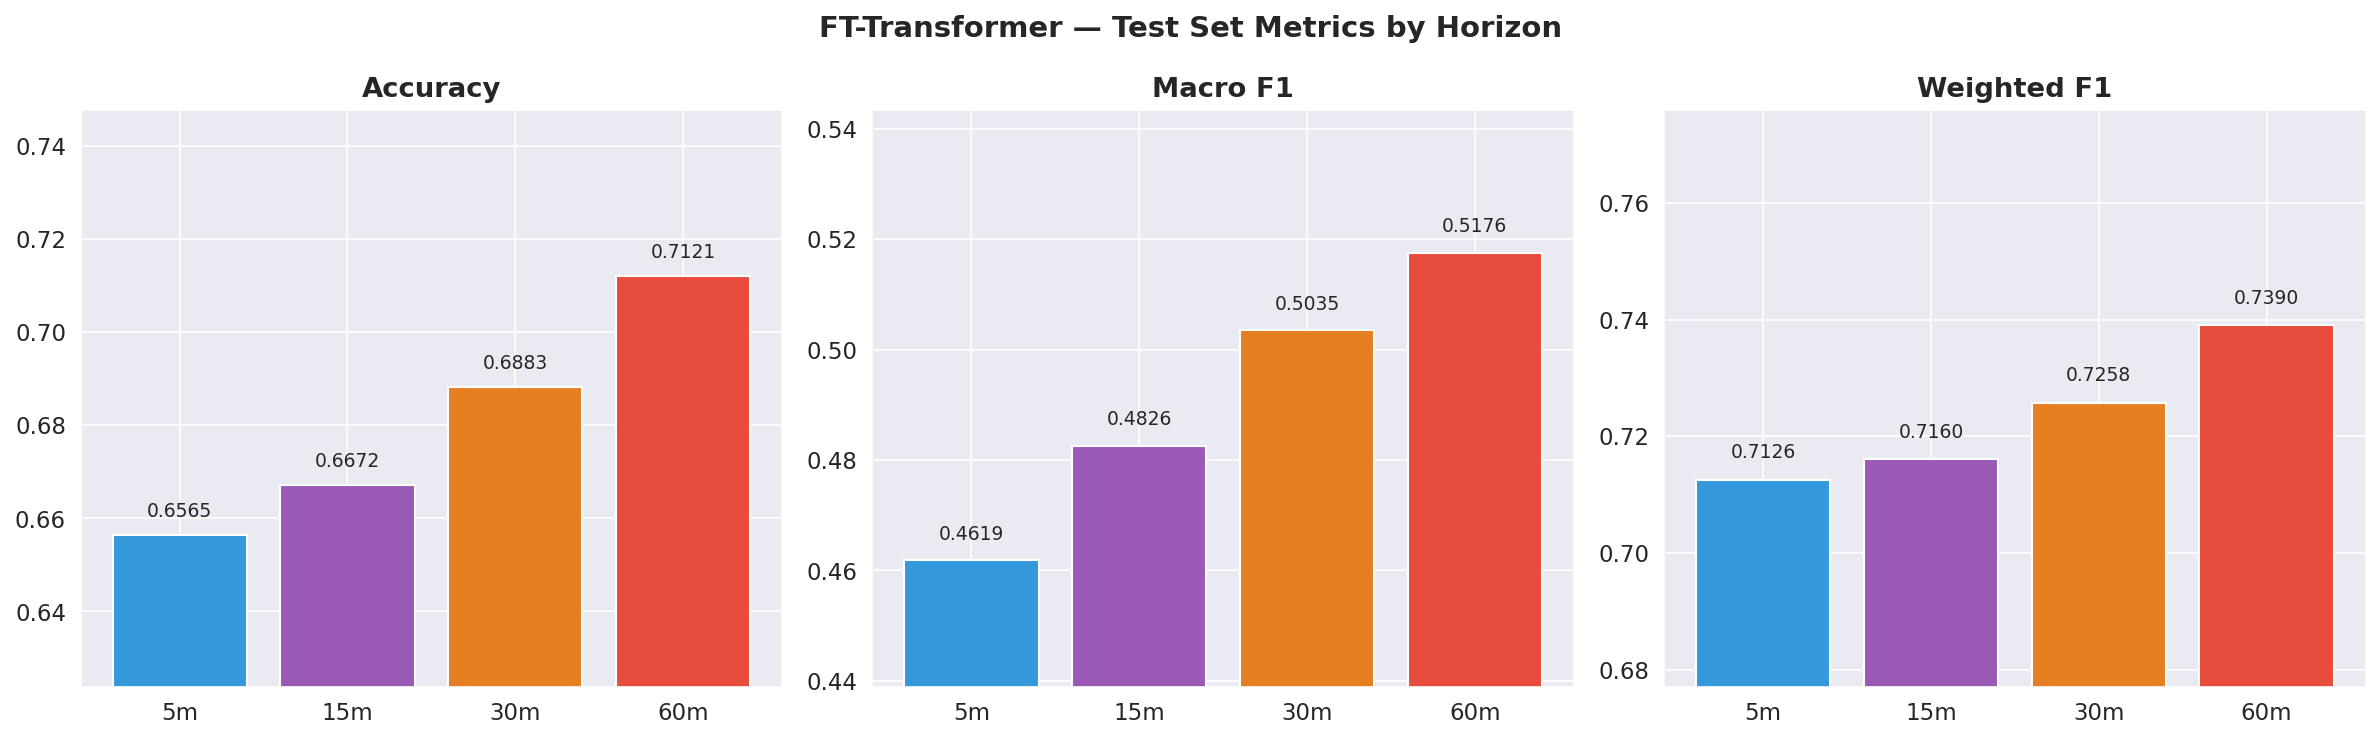

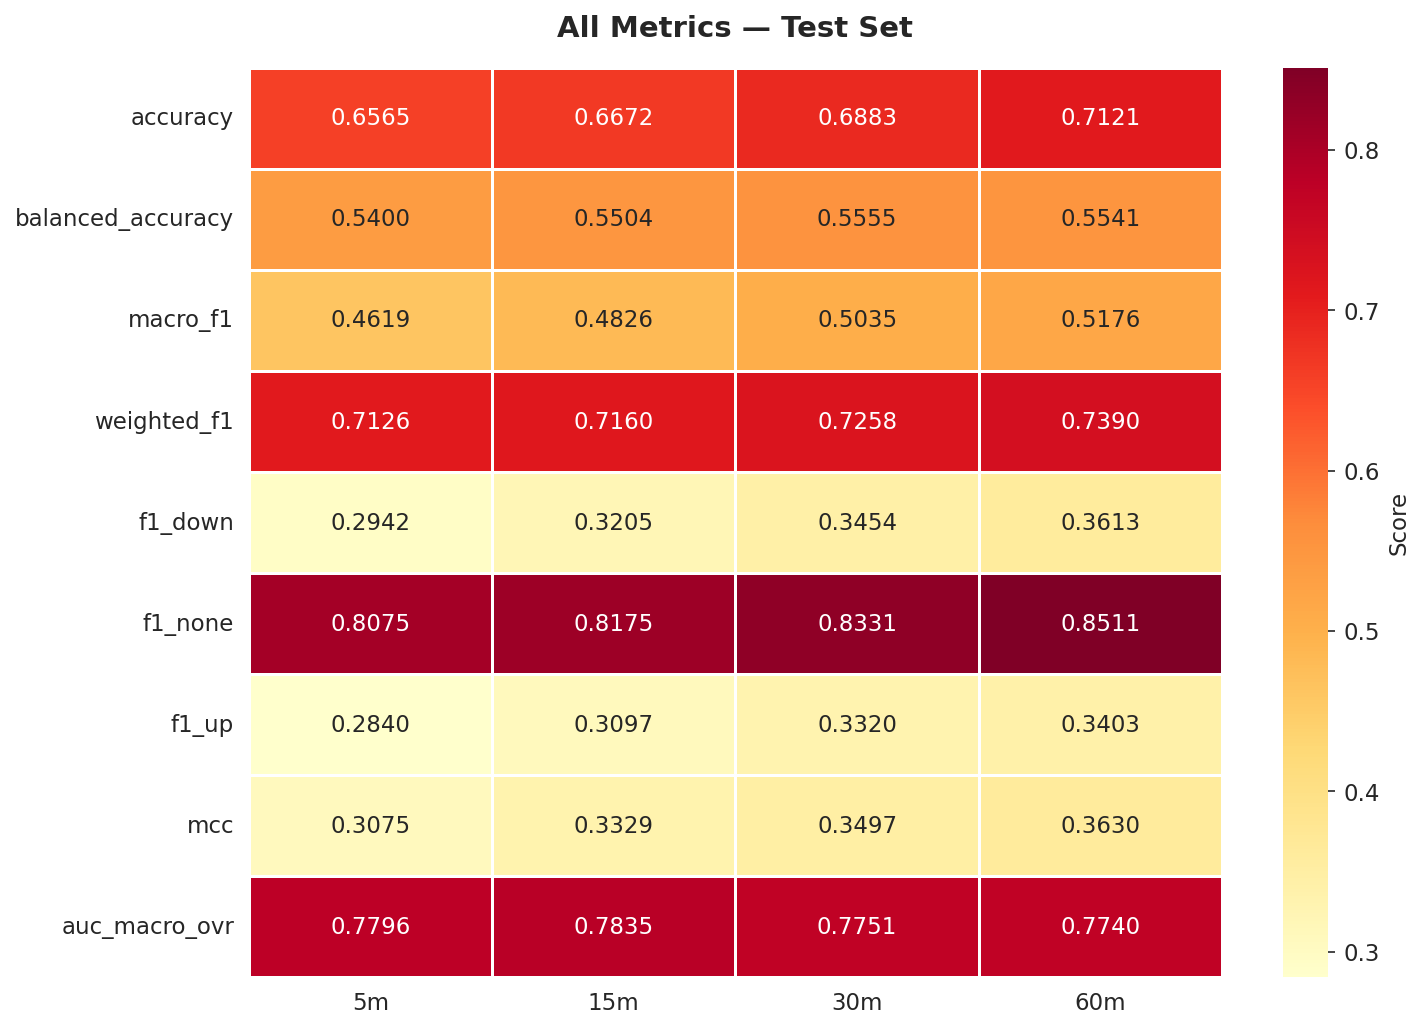

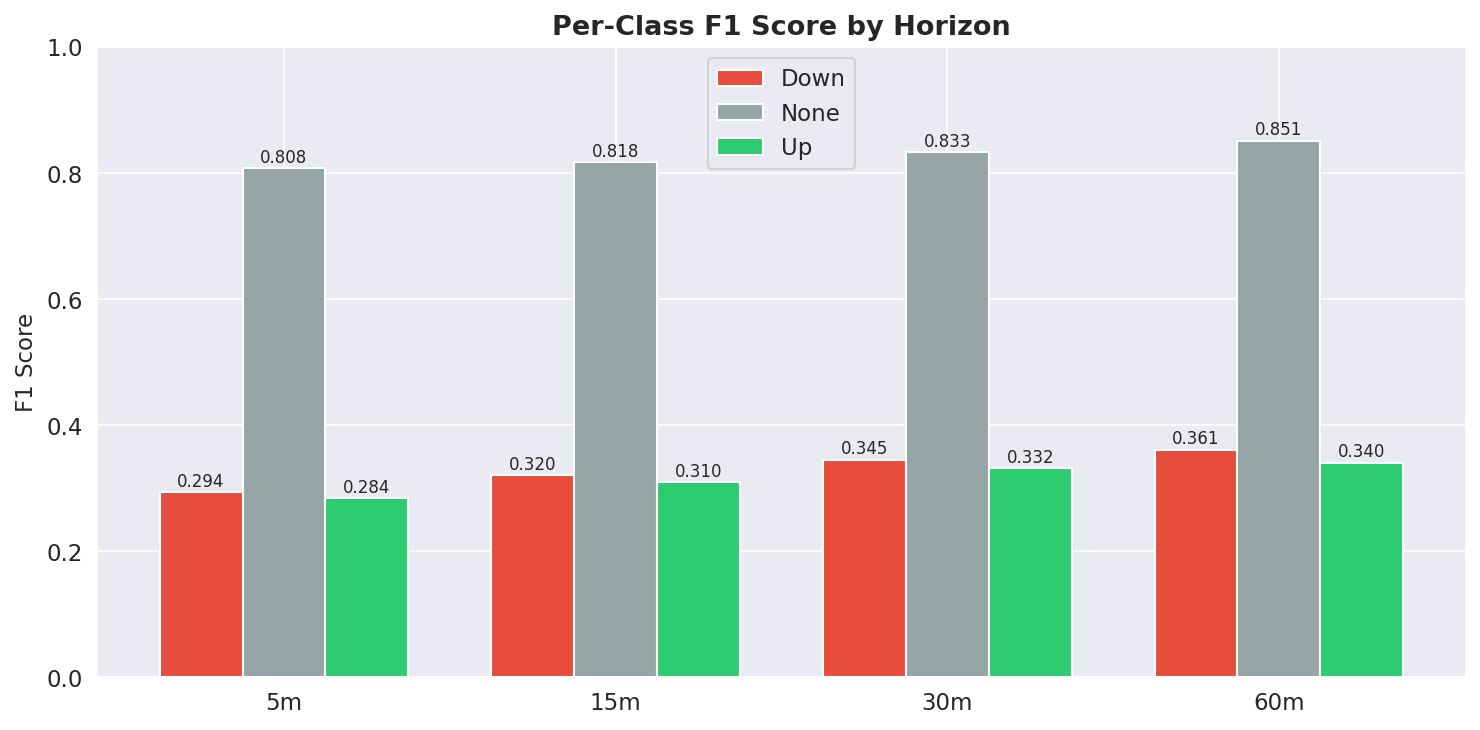

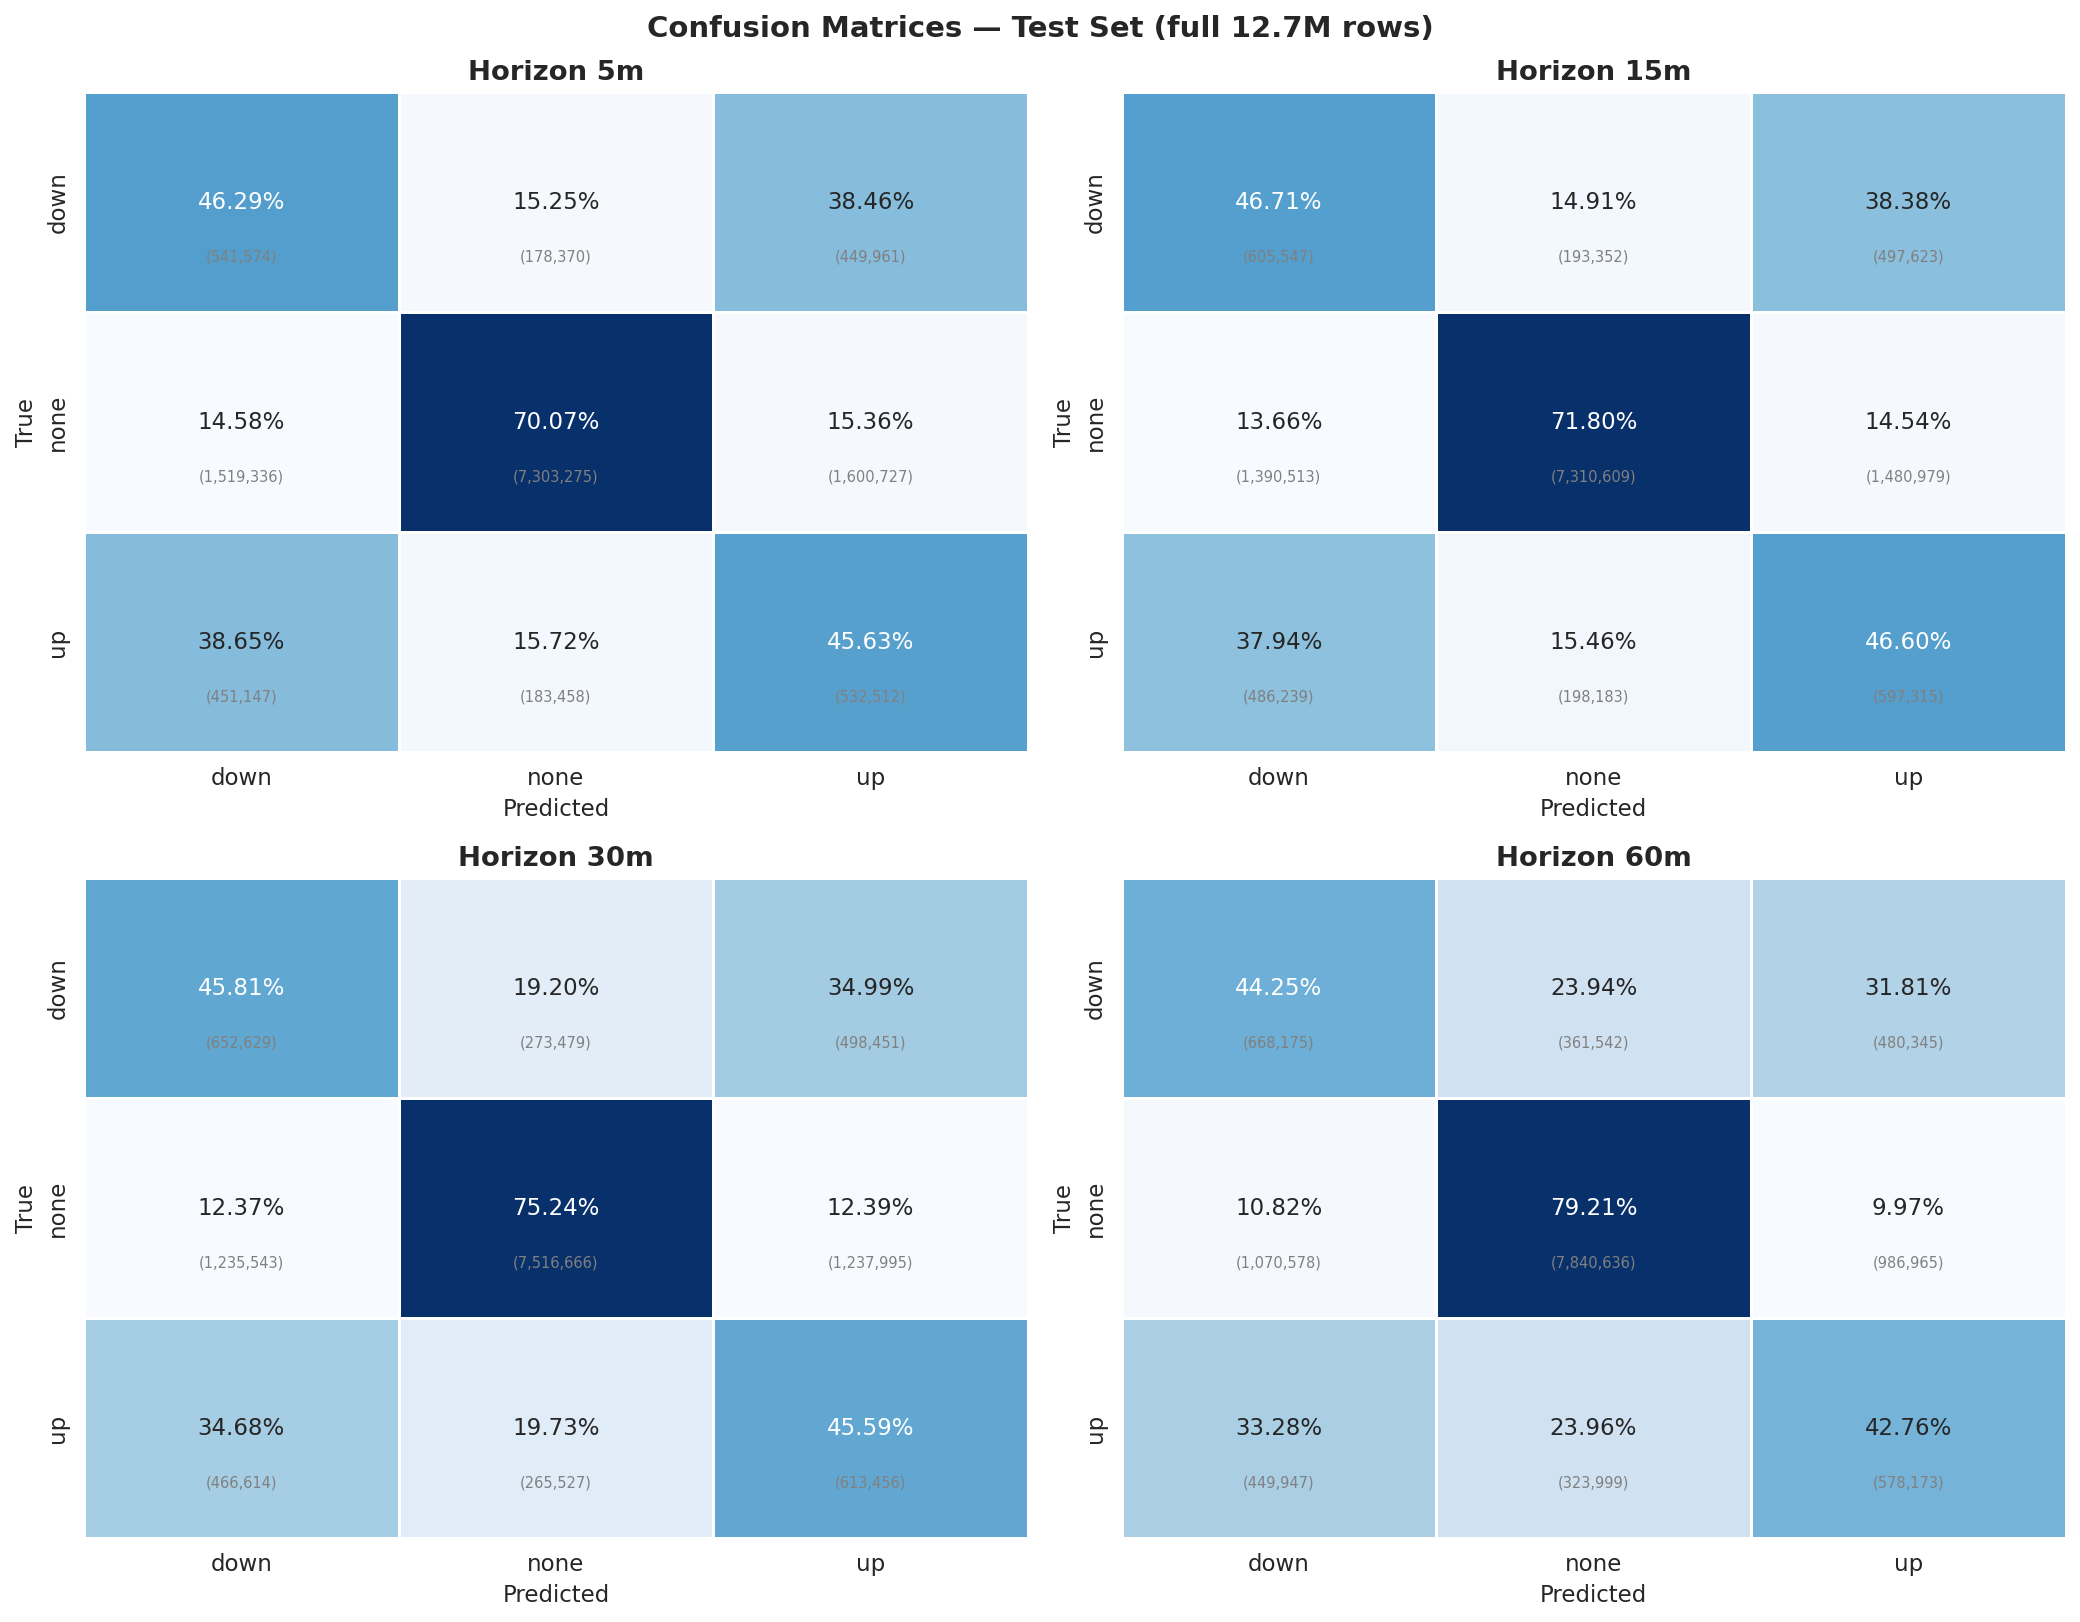

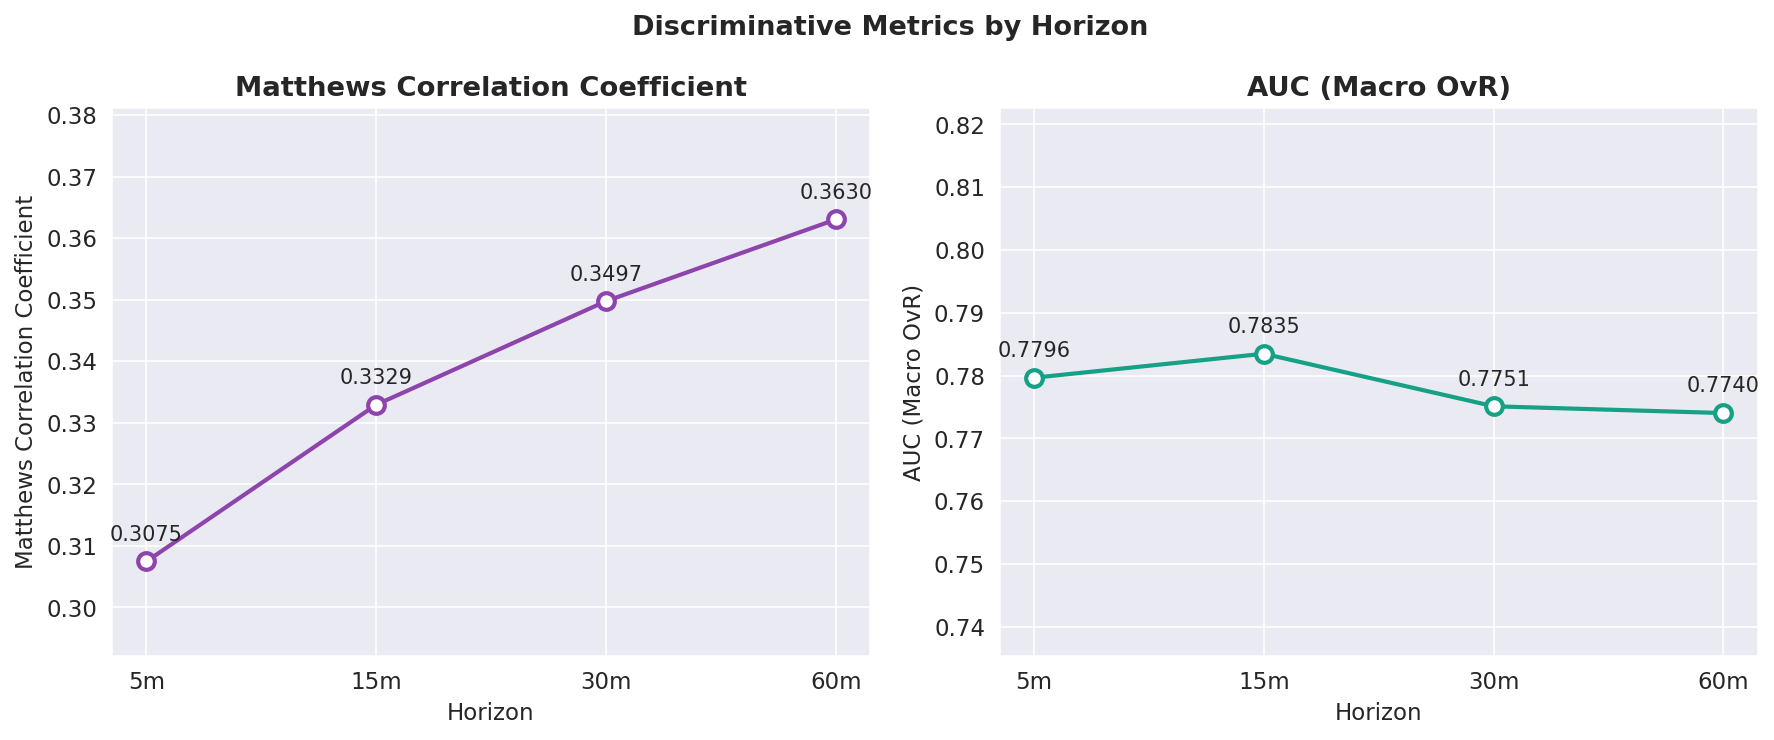

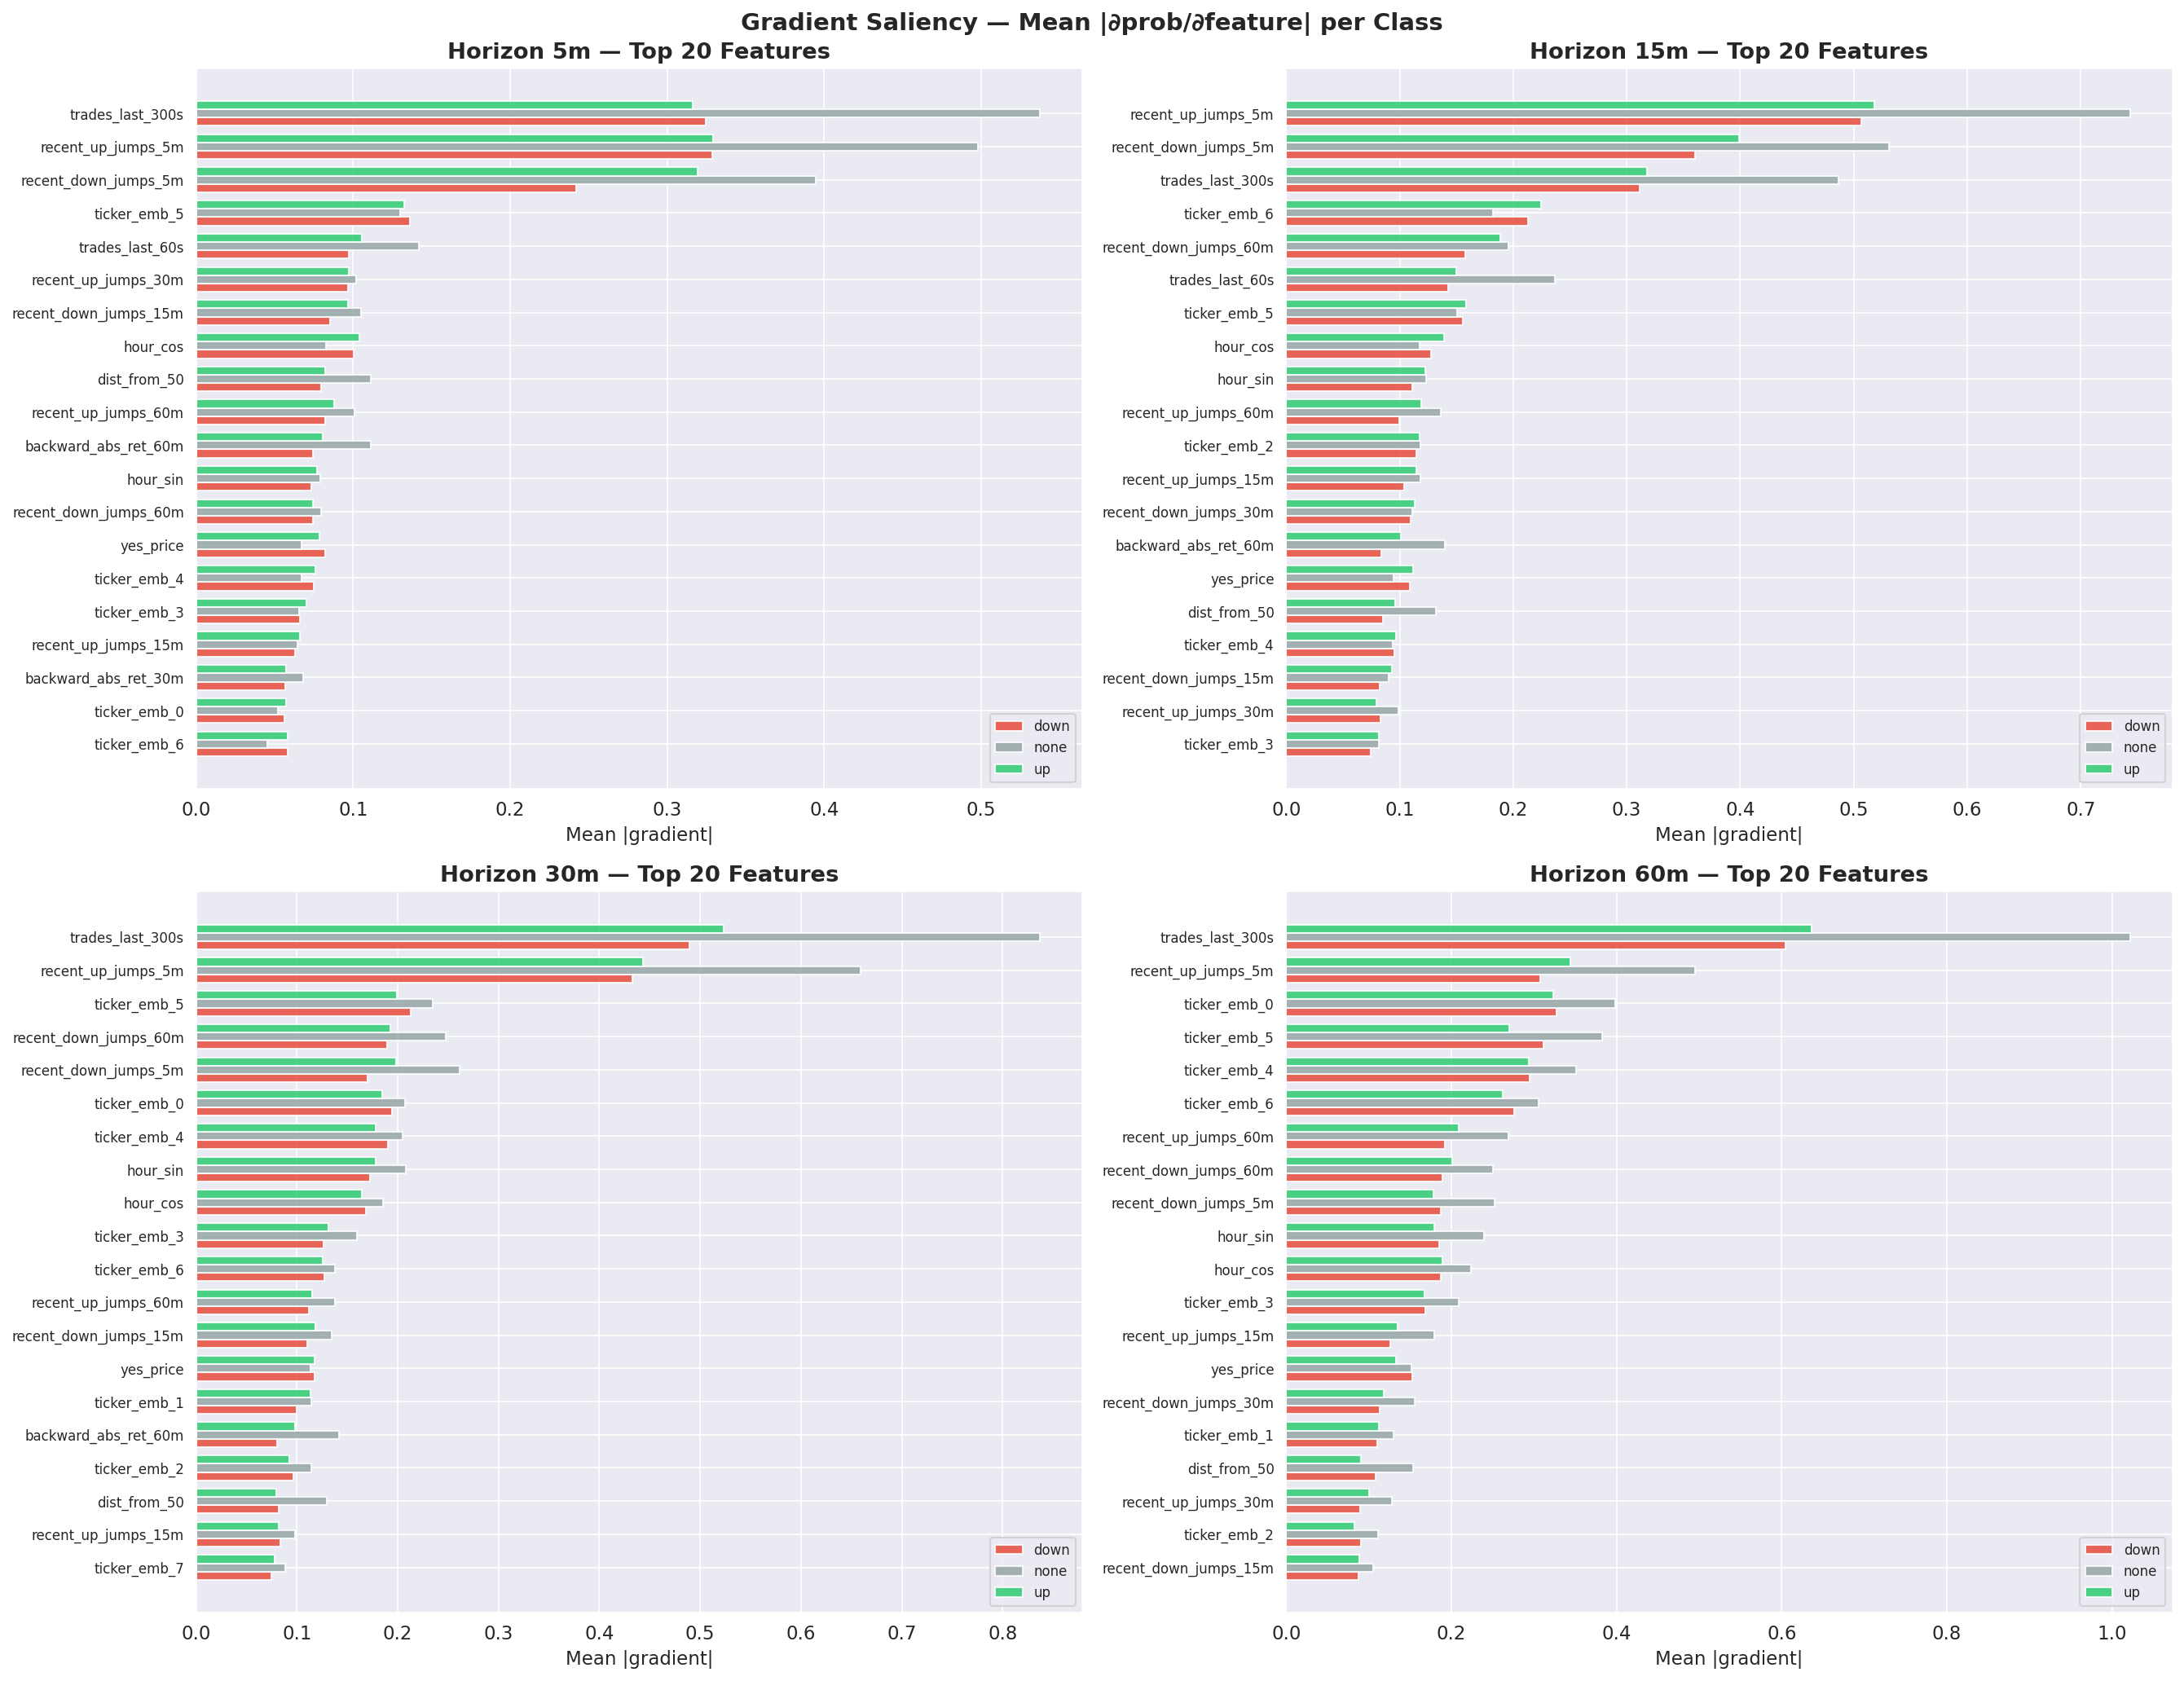

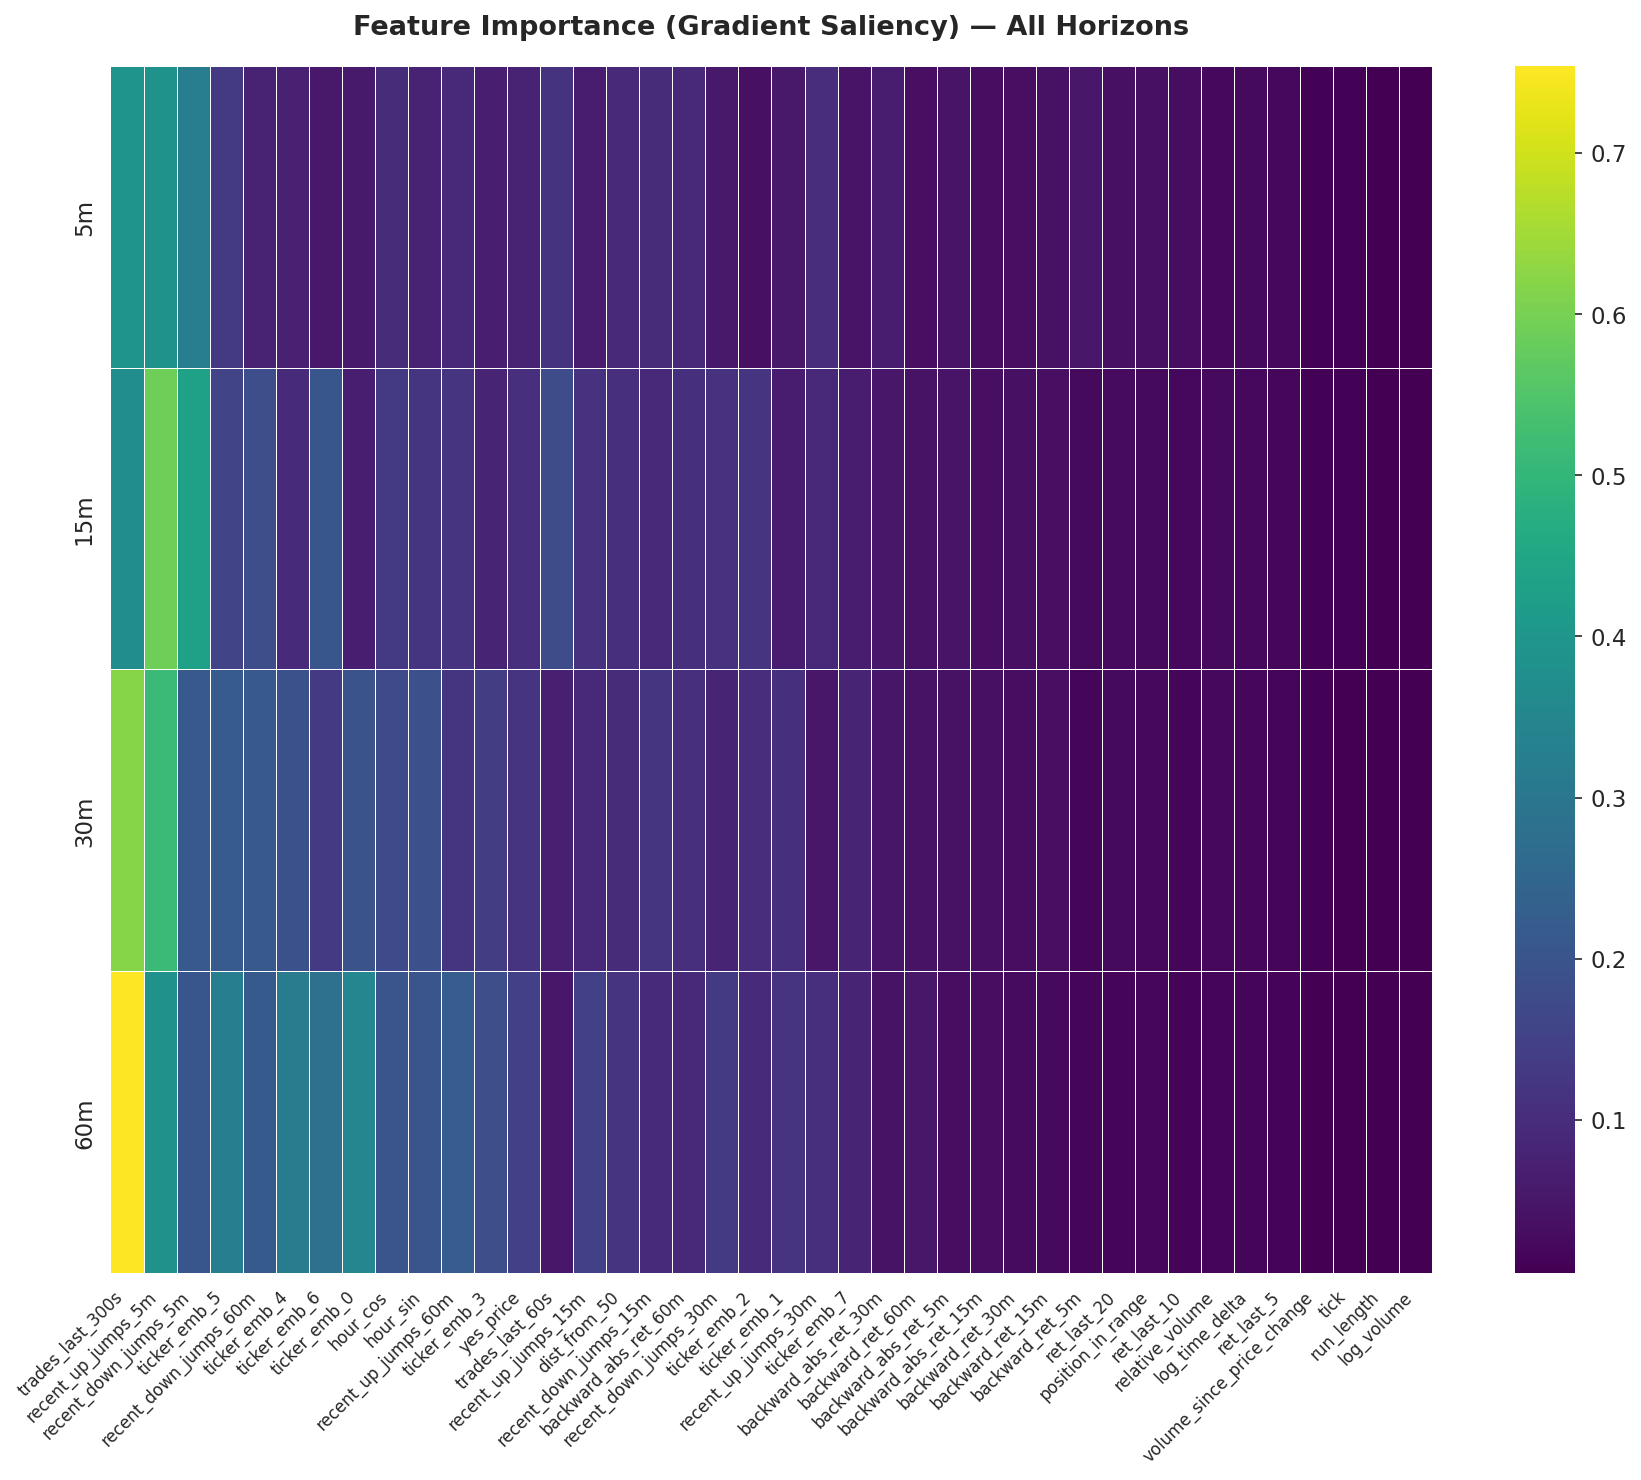

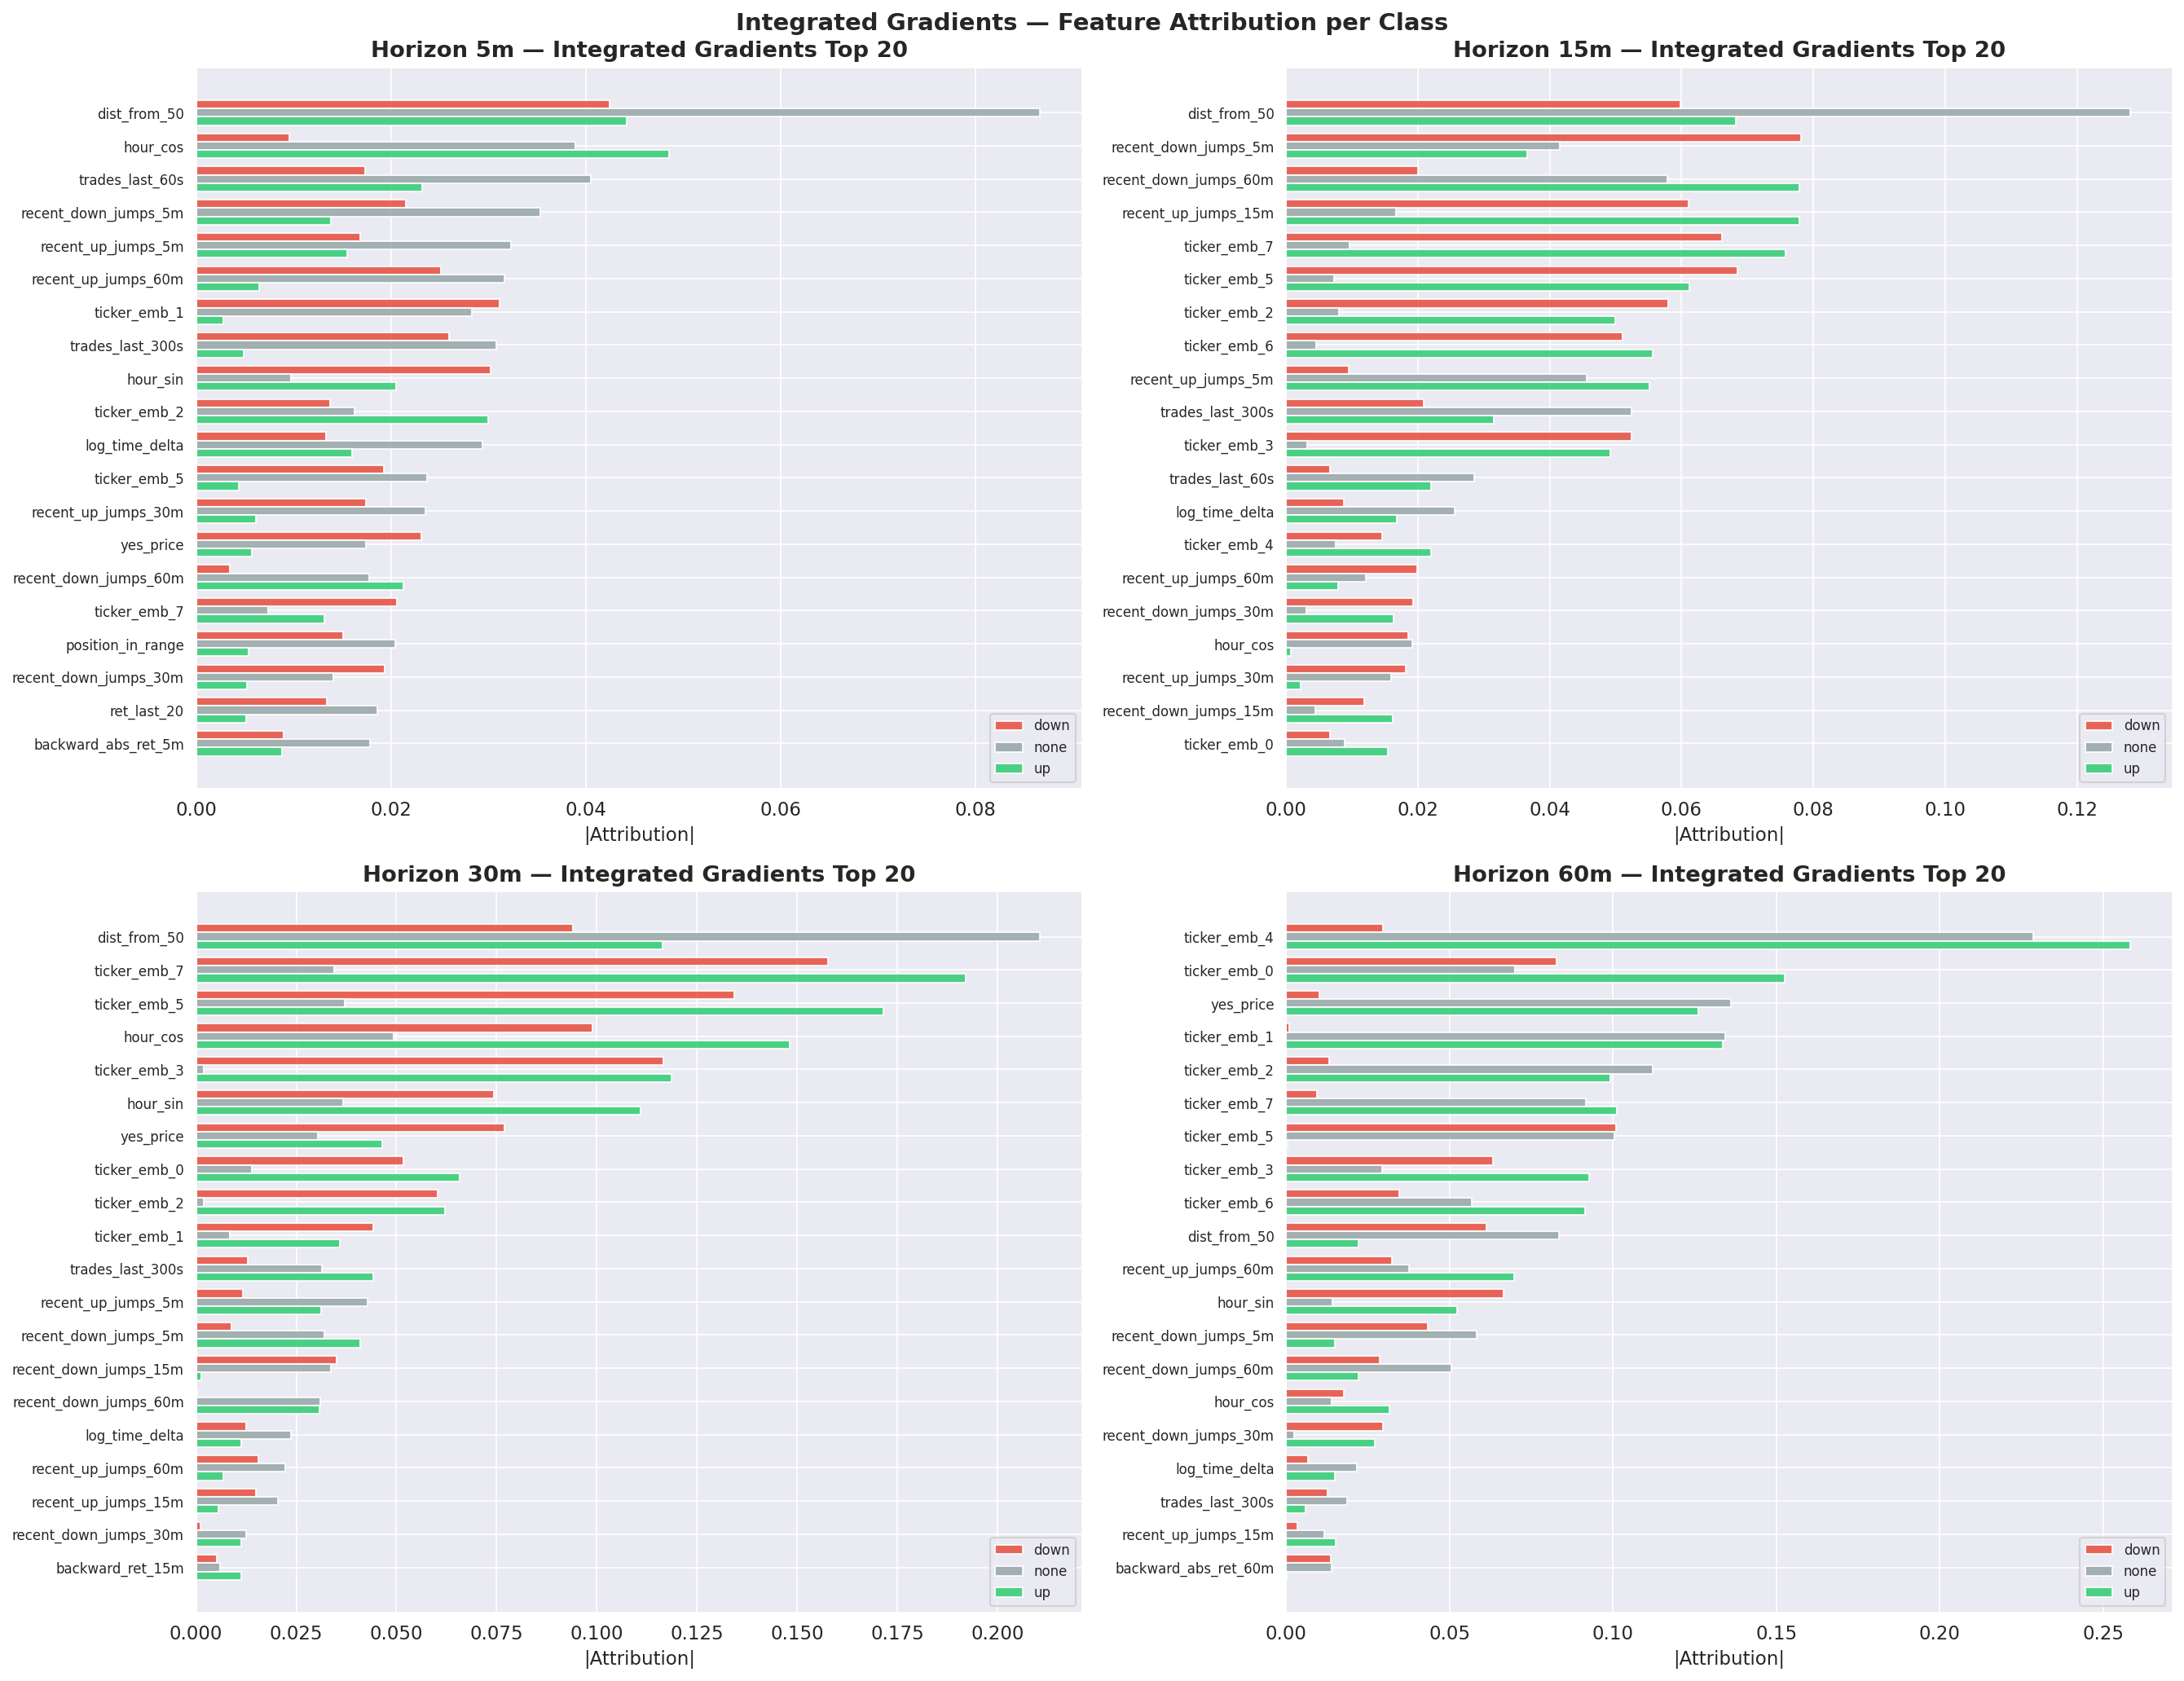

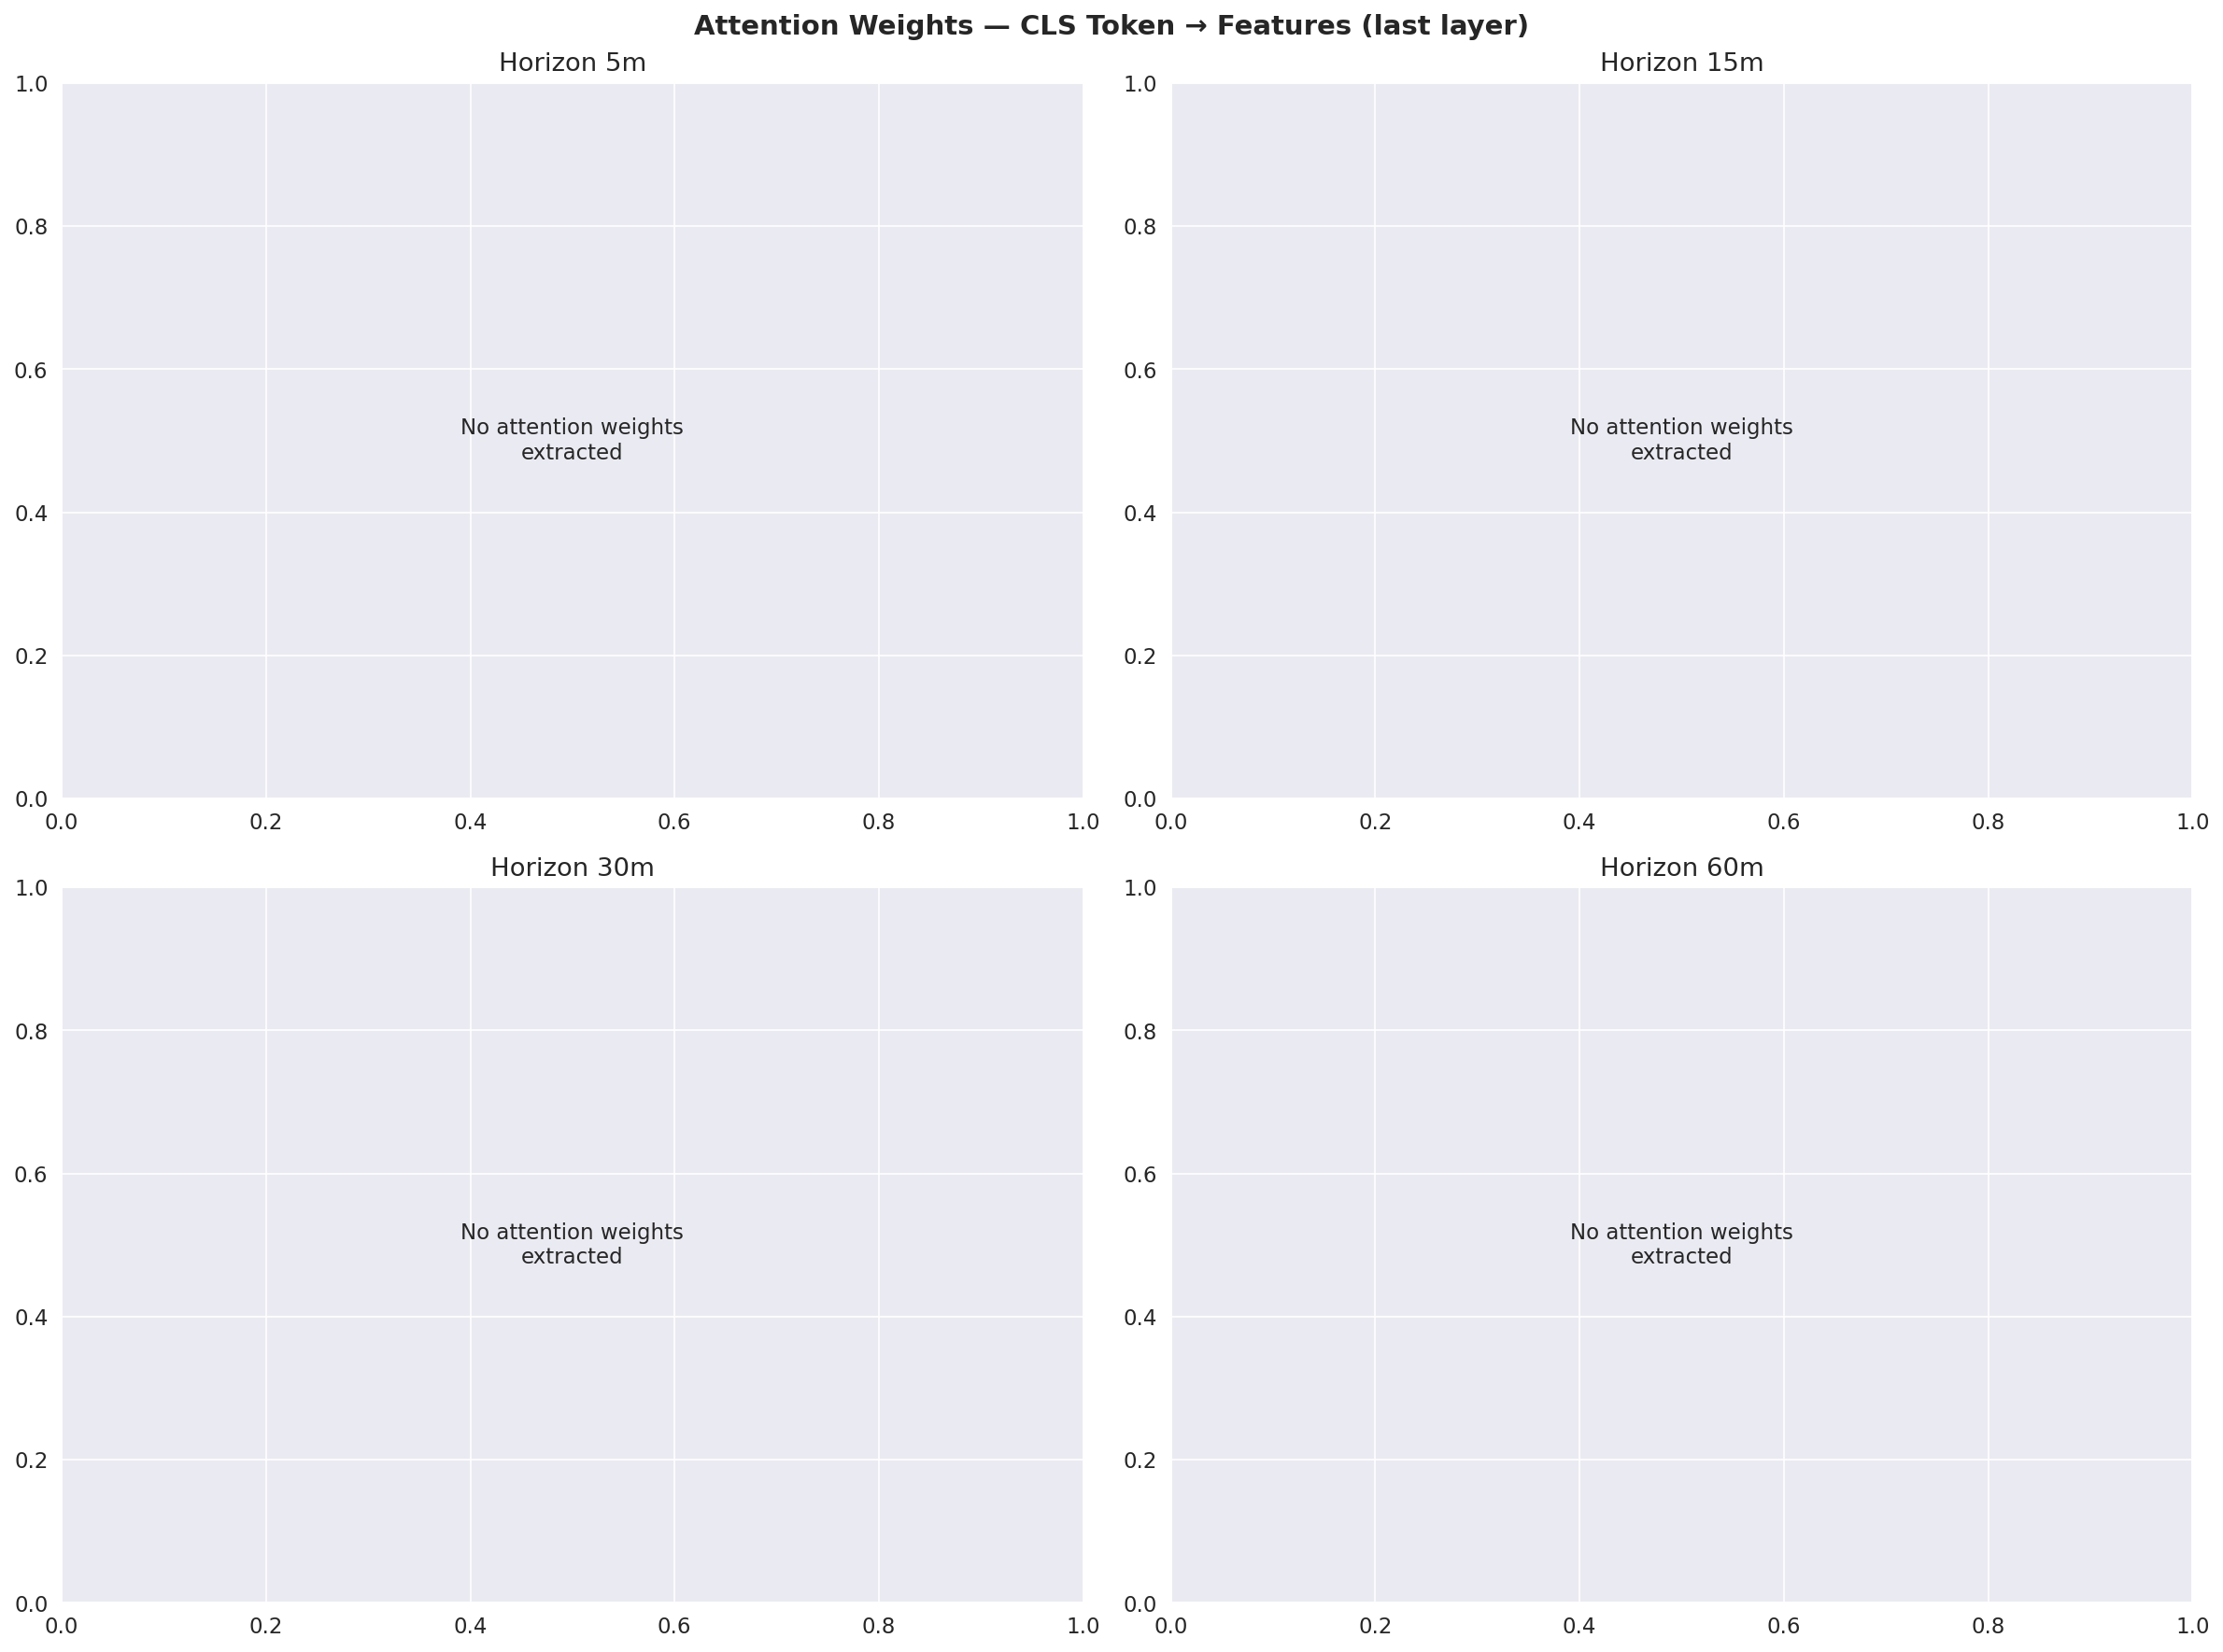

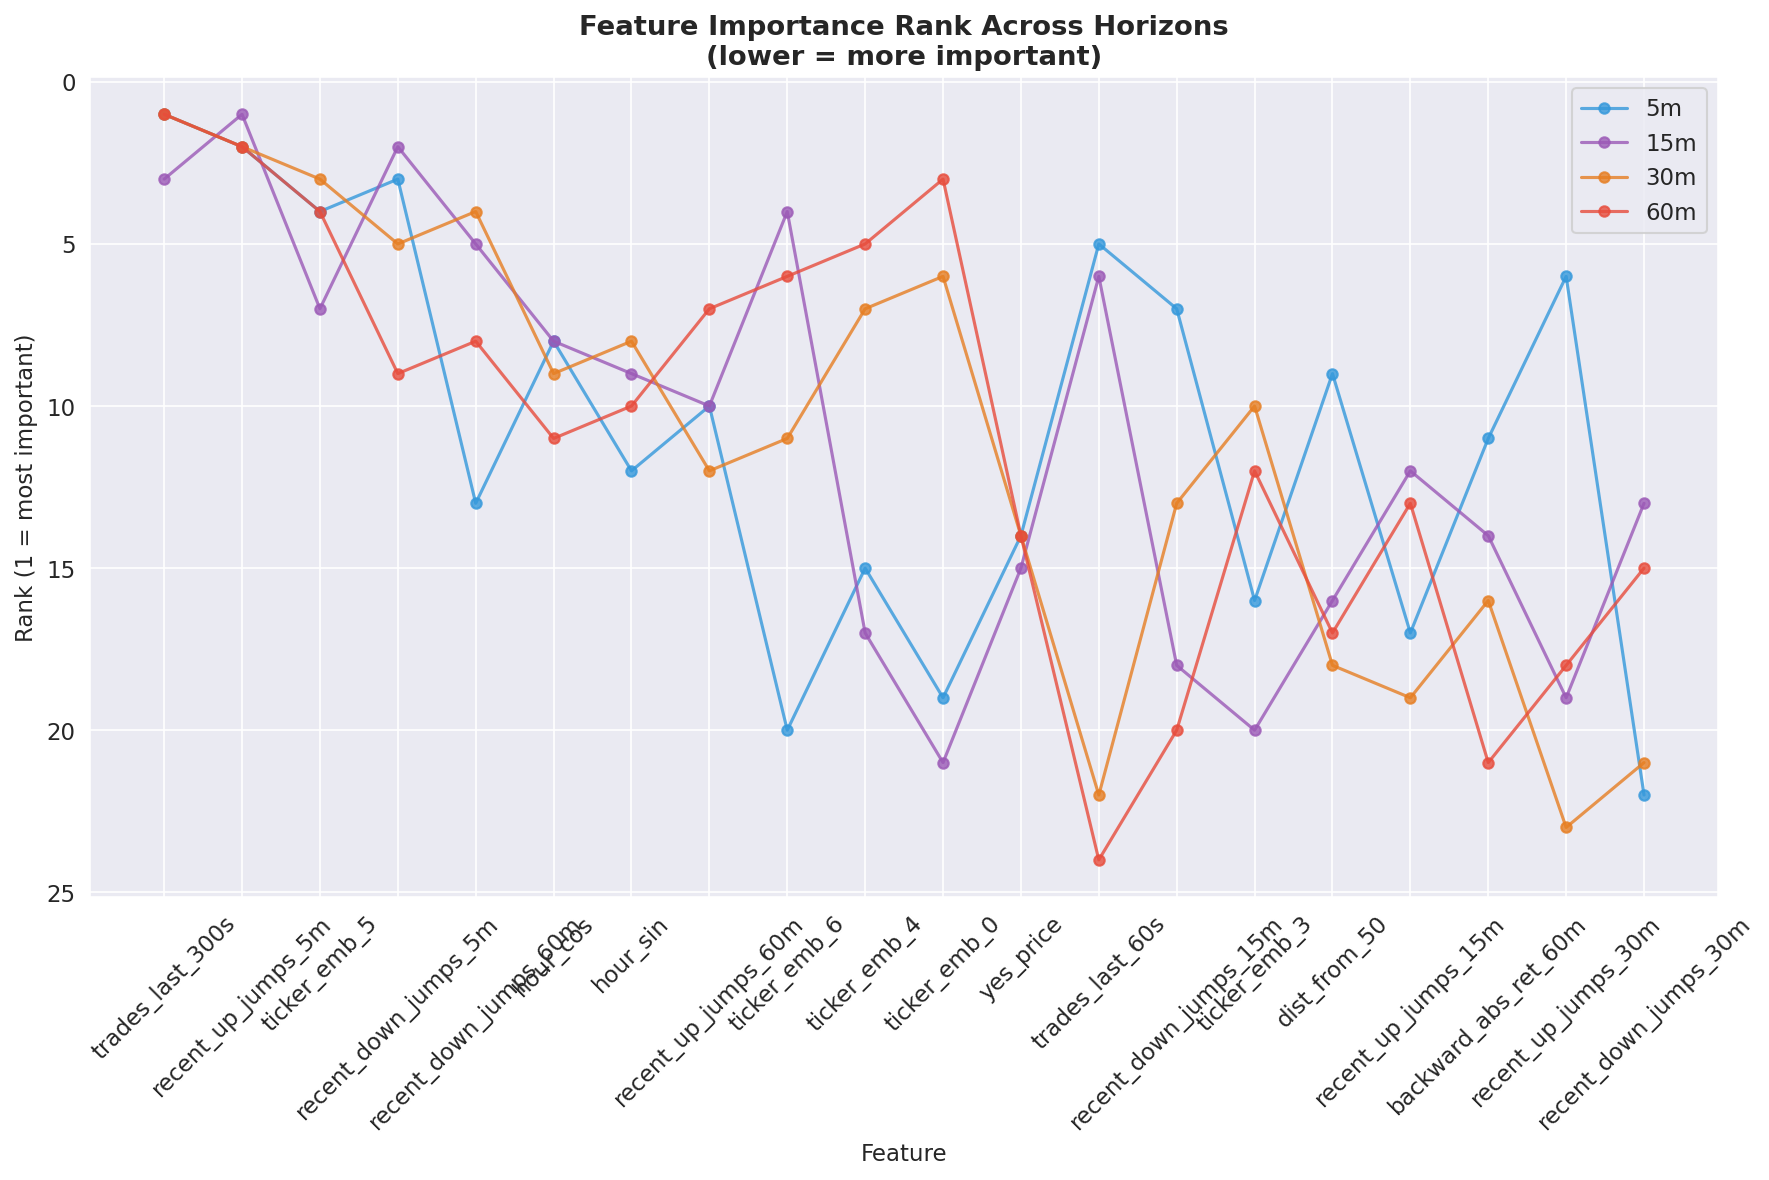


── Top 10 Features (avg saliency across all horizons & classes) ──
   1. trades_last_300s                     0.533843
   2. recent_up_jumps_5m                   0.467108
   3. recent_down_jumps_5m                 0.291087
   4. ticker_emb_5                         0.206275
   5. recent_down_jumps_60m                0.170099
   6. ticker_emb_4                         0.168080
   7. ticker_emb_6                         0.167995
   8. ticker_emb_0                         0.166824
   9. hour_cos                             0.149141
  10. hour_sin                             0.145779


In [ ]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})
COLORS   = {'down': '#e74c3c', 'none': '#95a5a6', 'up': '#2ecc71'}
H_COLORS = {5: '#3498db', 15: '#9b59b6', 30: '#e67e22', 60: '#e74c3c'}
CLASS_NAMES = ['down', 'none', 'up']

# ── Plot 1: Metrics overview ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FT-Transformer — Test Set Metrics by Horizon', fontsize=14, fontweight='bold')
for ax, (metric, label) in zip(axes, [('accuracy','Accuracy'),('macro_f1','Macro F1'),('weighted_f1','Weighted F1')]):
    vals = [metrics_all[h][metric] for h in HORIZONS]
    bars = ax.bar([f'{h}m' for h in HORIZONS], vals, color=[H_COLORS[h] for h in HORIZONS], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontweight='bold'); ax.set_ylim(min(vals)*0.95, max(vals)*1.05)
plt.tight_layout(); plt.show()

# ── Plot 2: Metrics heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
metric_list = ['accuracy','balanced_accuracy','macro_f1','weighted_f1','f1_down','f1_none','f1_up','mcc','auc_macro_ovr']
data = np.array([[metrics_all[h][m] for h in HORIZONS] for m in metric_list])
sns.heatmap(data, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'{h}m' for h in HORIZONS], yticklabels=metric_list,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('All Metrics — Test Set', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

# ── Plot 3: Per-class F1 ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS)); w = 0.25
for i, cls in enumerate(['down','none','up']):
    vals = [metrics_all[h][f'f1_{cls}'] for h in HORIZONS]
    bars = ax.bar(x+(i-1)*w, vals, w, label=cls.capitalize(), color=COLORS[cls], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}m' for h in HORIZONS])
ax.set_ylabel('F1 Score'); ax.set_title('Per-Class F1 Score by Horizon', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout(); plt.show()

# ── Plot 4: Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — Test Set (full 12.7M rows)', fontsize=14, fontweight='bold')
for ax, h in zip(axes.flatten(), HORIZONS):
    cm   = np.array(metrics_all[h]['confusion_matrix'])
    cm_n = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, cbar=False)
    for i in range(3):
        for j in range(3):
            ax.text(j+0.5, i+0.75, f'({cm[i,j]:,})', ha='center', va='center', fontsize=7, color='grey')
    ax.set_title(f'Horizon {h}m', fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# ── Plot 5: MCC and AUC ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (metric, label, color) in zip(axes, [('mcc','Matthews Correlation Coefficient','#8e44ad'),('auc_macro_ovr','AUC (Macro OvR)','#16a085')]):
    vals = [metrics_all[h][metric] for h in HORIZONS]
    ax.plot([f'{h}m' for h in HORIZONS], vals, 'o-', color=color, linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    for x, v in zip([f'{h}m' for h in HORIZONS], vals):
        ax.annotate(f'{v:.4f}', (x, v), textcoords='offset points', xytext=(0,10), ha='center', fontsize=10)
    ax.set_title(label, fontweight='bold'); ax.set_ylabel(label); ax.set_xlabel('Horizon')
    ax.set_ylim(min(vals)*0.95, max(vals)*1.05)
plt.suptitle('Discriminative Metrics by Horizon', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plot 6: Gradient Saliency per horizon ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Gradient Saliency — Mean |∂prob/∂feature| per Class', fontsize=14, fontweight='bold')
for ax, h in zip(axes.flatten(), HORIZONS):
    sal = saliency_all[h]; sal_mean = sal.mean(axis=0); order = np.argsort(sal_mean)[::-1]
    top_n = 20; feats = [FEATURE_COLS[i] for i in order[:top_n]]; y = np.arange(top_n); w = 0.25
    ax.barh(y+w,  sal[0, order[:top_n]], w, label='down', color=COLORS['down'], alpha=0.85)
    ax.barh(y,    sal[1, order[:top_n]], w, label='none', color=COLORS['none'], alpha=0.85)
    ax.barh(y-w,  sal[2, order[:top_n]], w, label='up',   color=COLORS['up'],   alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(feats, fontsize=8)
    ax.set_title(f'Horizon {h}m — Top {top_n} Features', fontweight='bold')
    ax.set_xlabel('Mean |gradient|'); ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Plot 7: Saliency heatmap across horizons ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
sal_matrix  = np.stack([saliency_all[h].mean(axis=0) for h in HORIZONS], axis=0)
feat_order  = np.argsort(sal_matrix.mean(axis=0))[::-1]
sns.heatmap(sal_matrix[:, feat_order], annot=False, cmap='viridis', ax=ax,
            xticklabels=[FEATURE_COLS[i] for i in feat_order],
            yticklabels=[f'{h}m' for h in HORIZONS], linewidths=0.3)
ax.set_xticklabels([FEATURE_COLS[i] for i in feat_order], rotation=45, ha='right', fontsize=8)
ax.set_title('Feature Importance (Gradient Saliency) — All Horizons', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

# ── Plot 8: Integrated Gradients ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Integrated Gradients — Feature Attribution per Class', fontsize=14, fontweight='bold')
for ax, h in zip(axes.flatten(), HORIZONS):
    ig = ig_all[h]; ig_mean = np.abs(ig).mean(axis=0); order = np.argsort(ig_mean)[::-1]
    top_n = 20; feats = [FEATURE_COLS[i] for i in order[:top_n]]; y = np.arange(top_n); w = 0.25
    for ci, (cls, col) in enumerate(COLORS.items()):
        ax.barh(y+(ci-1)*w, np.abs(ig[ci, order[:top_n]]), w, label=cls, color=col, alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(feats, fontsize=8)
    ax.set_title(f'Horizon {h}m — Integrated Gradients Top {top_n}', fontweight='bold')
    ax.set_xlabel('|Attribution|'); ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Plot 9: Attention weights ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Attention Weights — CLS Token → Features (last layer)', fontsize=14, fontweight='bold')
for ax, h in zip(axes.flatten(), HORIZONS):
    attn = attention_all[h]
    if attn is None or len(attn) == 0:
        ax.text(0.5, 0.5, 'No attention weights\nextracted', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Horizon {h}m'); continue
    cls_attn = attn[-1][0, 1:]; order = np.argsort(cls_attn)[::-1]; top_n = 20
    ax.barh([FEATURE_COLS[i] for i in order[:top_n]], cls_attn[order[:top_n]], color=H_COLORS[h], alpha=0.85, edgecolor='white')
    ax.set_title(f'Horizon {h}m — CLS attention top {top_n}', fontweight='bold')
    ax.set_xlabel('Attention weight'); ax.invert_yaxis(); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

# ── Plot 10: Feature rank consensus ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
ranks = np.zeros((len(HORIZONS), N_FEATURES))
for i, h in enumerate(HORIZONS):
    order = np.argsort(saliency_all[h].mean(axis=0))[::-1]
    for rank, feat_idx in enumerate(order):
        ranks[i, feat_idx] = rank + 1
avg_rank = ranks.mean(axis=0); order = np.argsort(avg_rank); top_n = 20
feats = [FEATURE_COLS[i] for i in order[:top_n]]
for i, h in enumerate(HORIZONS):
    ax.plot(feats, ranks[i, order[:top_n]], 'o-', label=f'{h}m', color=H_COLORS[h], linewidth=1.5, markersize=5, alpha=0.8)
ax.set_ylabel('Rank (1 = most important)'); ax.set_xlabel('Feature')
ax.set_title('Feature Importance Rank Across Horizons\n(lower = more important)', fontweight='bold')
ax.tick_params(axis='x', rotation=45); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Top 10 features summary ───────────────────────────────────────────────────
print('\n── Top 10 Features (avg saliency across all horizons & classes) ──')
avg_sal = np.stack([saliency_all[h].mean(axis=0) for h in HORIZONS]).mean(axis=0)
for rank, i in enumerate(np.argsort(avg_sal)[::-1][:10]):
    print(f'  {rank+1:>2}. {FEATURE_COLS[i]:<35}  {avg_sal[i]:.6f}')

In [ ]:
!pip install -q rtdl --no-deps

In [ ]:
import os, gc, json, pickle
import numpy as np
import torch
import rtdl
from google.colab import drive

drive.mount('/content/drive')

PREP_DIR   = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR   = os.path.join(PREP_DIR, 'checkpoints')
HORIZONS   = [5, 15, 30, 60]
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)

N_FEATURES   = meta['n_features']
N_TEST       = meta['n_test']
FEATURE_COLS = meta['feature_cols']

models = {}
for h in HORIZONS:
    ckpt_path = os.path.join(CKPT_DIR, f'horizon_{h}m', 'best.pt')
    model = rtdl.FTTransformer.make_default(
        n_num_features=N_FEATURES, cat_cardinalities=[],
        last_layer_query_idx=[-1], d_out=3)
    state = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(state if not (isinstance(state, dict) and 'model' in state)
                          else state['model'])
    model.eval()
    models[h] = model
    print(f'  horizon {h}m loaded ✅')

print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print('Ready.')

Mounted at /content/drive
  horizon 5m loaded ✅
  horizon 15m loaded ✅
  horizon 30m loaded ✅
  horizon 60m loaded ✅
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Ready.


In [ ]:
# =============================================================================
# FT-TRANSFORMER — Paper-ready metrics (matching LightGBM/LSTM/Mamba format)
# =============================================================================
# Outputs:
#   1. Headline metrics table (balanced acc, macro F1, weighted F1, accuracy)
#   2. Per-class precision, recall, F1 table
#   3. Confusion matrix as numbers (for LaTeX table, not plot)
#   4. Top 25 features by gradient saliency (overall, not per-class)
#   5. AUC + MCC table
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports (assumes verify script already ran)
# ─────────────────────────────────────────────────────────────────────────────
import os, gc, json, pickle
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix,
    precision_score, recall_score, classification_report
)

PREP_DIR   = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR   = os.path.join(PREP_DIR, 'checkpoints')
HORIZONS   = [5, 15, 30, 60]
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED       = 42

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)

N_FEATURES   = meta['n_features']
N_TEST       = meta['n_test']
FEATURE_COLS = meta['feature_cols']

import rtdl
if 'models' not in dir():
    models = {}
    for h in HORIZONS:
        ckpt_path = os.path.join(CKPT_DIR, f'horizon_{h}m', 'best.pt')
        model = rtdl.FTTransformer.make_default(
            n_num_features=N_FEATURES, cat_cardinalities=[],
            last_layer_query_idx=[-1], d_out=3)
        state = torch.load(ckpt_path, map_location='cpu')
        model.load_state_dict(state if not (isinstance(state, dict) and 'model' in state)
                              else state['model'])
        model.eval()
        models[h] = model
    print('Models loaded.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Full test set inference (all 4 models)
# ─────────────────────────────────────────────────────────────────────────────
print('Loading full test set...')
X_test = np.memmap(os.path.join(PREP_DIR, 'X_test.npy'),
                   dtype=np.float32, mode='r', shape=(N_TEST, N_FEATURES))
X_test_np = np.array(X_test)   # materialise fully
del X_test; gc.collect()
print(f'X_test loaded: {X_test_np.shape}')

Y_test = {}
for h in HORIZONS:
    y = np.memmap(os.path.join(PREP_DIR, f'y_{h}m_test.npy'),
                  dtype=np.int8, mode='r', shape=(N_TEST,))
    Y_test[h] = np.array(y).astype(np.int64)

BATCH = 8192
all_probs = {}
all_preds = {}

for h in HORIZONS:
    print(f'\nInference horizon {h}m ...')
    model = models[h].to(DEVICE)
    model.eval()
    probs_list = []

    with torch.no_grad():
        for i in range(0, N_TEST, BATCH):
            xb = torch.from_numpy(X_test_np[i:i+BATCH]).to(DEVICE)
            logits = model(xb, None)
            probs_list.append(torch.softmax(logits, dim=-1).cpu().numpy())
            if i % (BATCH * 100) == 0:
                print(f'  {i:,}/{N_TEST:,} ...', end='\r')

    p = np.concatenate(probs_list, axis=0)
    all_probs[h] = p
    all_preds[h] = p.argmax(axis=1)
    model.to('cpu')
    torch.cuda.empty_cache(); gc.collect()
    print(f'  horizon {h}m done.')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Compute all metrics
# ─────────────────────────────────────────────────────────────────────────────
results = {}
CLASS_NAMES = ['down', 'none', 'up']   # 0, 1, 2

for h in HORIZONS:
    y_true = Y_test[h]
    y_pred = all_preds[h]
    y_prob = all_probs[h]

    acc      = accuracy_score(y_true, y_pred)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    mac_f1   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wt_f1    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mcc      = matthews_corrcoef(y_true, y_pred)
    auc      = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    cm       = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    prec_per = precision_score(y_true, y_pred, average=None, zero_division=0, labels=[0,1,2])
    rec_per  = recall_score   (y_true, y_pred, average=None, zero_division=0, labels=[0,1,2])
    f1_per   = f1_score       (y_true, y_pred, average=None, zero_division=0, labels=[0,1,2])

    results[h] = {
        'acc': acc, 'bal_acc': bal_acc,
        'mac_f1': mac_f1, 'wt_f1': wt_f1,
        'mcc': mcc, 'auc': auc, 'cm': cm,
        'prec': prec_per, 'rec': rec_per, 'f1': f1_per,
    }

# CELL 4 — Saliency fix: separate backward per class, train mode
SALIENCY_N = 50_000
rng  = np.random.default_rng(SEED)
idx  = rng.choice(N_TEST, size=SALIENCY_N, replace=False); idx.sort()
X_sal = X_test_np[idx]

saliency_overall = {}  # horizon -> [n_features]

for h in HORIZONS:
    print(f'Saliency horizon {h}m ...', end=' ')
    model = models[h].to(DEVICE)
    model.train()  # needed for gradient flow in rtdl

    sal = np.zeros(N_FEATURES, dtype=np.float64)
    count = 0

    for i in range(0, SALIENCY_N, 2048):
        xb = torch.from_numpy(X_sal[i:i+2048].astype(np.float32)).to(DEVICE)
        xb.requires_grad_(True)

        logits = model(xb, None)
        probs  = torch.softmax(logits, dim=-1)  # [B, 3]

        # separate backward per class, accumulate |grad|
        for c in range(3):
            model.zero_grad()
            if xb.grad is not None:
                xb.grad.zero_()
            probs[:, c].sum().backward(retain_graph=(c < 2))
            if xb.grad is not None:
                sal += xb.grad.abs().cpu().numpy().sum(axis=0)

        count += xb.shape[0]

    model.eval()
    model.to('cpu')
    torch.cuda.empty_cache(); gc.collect()
    saliency_overall[h] = sal / count
    print(f'done. max={saliency_overall[h].max():.6f}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — PRINT ALL TABLES (paper format)
# ─────────────────────────────────────────────────────────────────────────────

SEP = '─' * 70

# ── Table 1: Headline metrics ─────────────────────────────────────────────────
print('\n' + SEP)
print('TABLE 1 — Headline Metrics')
print(SEP)
print(f'{"Horizon":<10} {"Balanced acc":>14} {"Macro F1":>10} {"Weighted F1":>12} {"Accuracy":>10}')
print('─' * 50)
for h in HORIZONS:
    r = results[h]
    print(f'{str(h)+"m":<10} {r["bal_acc"]:>14.4f} {r["mac_f1"]:>10.4f} '
          f'{r["wt_f1"]:>12.4f} {r["acc"]:>10.4f}')

# ── Table 2: Per-class precision / recall / F1 ────────────────────────────────
print('\n' + SEP)
print('TABLE 2 — Per-Class Precision / Recall / F1')
print(SEP)
print(f'{"Horizon":<8} {"Class":<14} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('─' * 52)
for h in HORIZONS:
    r = results[h]
    for ci, cls in enumerate(['down ($-1$)', 'no jump ($0$)', 'up ($+1$)']):
        print(f'{str(h)+"m":<8} {cls:<14} {r["prec"][ci]:>10.4f} '
              f'{r["rec"][ci]:>8.4f} {r["f1"][ci]:>8.4f}')
    if h != HORIZONS[-1]:
        print('─' * 52)

# ── Table 3: Confusion matrices (numbers for LaTeX tabular) ──────────────────
print('\n' + SEP)
print('TABLE 3 — Confusion Matrices (for LaTeX table)')
print(SEP)
for h in HORIZONS:
    cm = results[h]['cm']
    print(f'\n  Horizon {h}m:')
    print(f'               Pred down    Pred none    Pred up')
    print(f'  True down    {cm[0,0]:>10,}  {cm[0,1]:>10,}  {cm[0,2]:>10,}')
    print(f'  True none    {cm[1,0]:>10,}  {cm[1,1]:>10,}  {cm[1,2]:>10,}')
    print(f'  True up      {cm[2,0]:>10,}  {cm[2,1]:>10,}  {cm[2,2]:>10,}')

# ── Table 4: AUC + MCC ────────────────────────────────────────────────────────
print('\n' + SEP)
print('TABLE 4 — AUC (macro OvR) and MCC')
print(SEP)
print(f'{"Horizon":<10} {"AUC (macro OvR)":>16} {"MCC":>8}')
print('─' * 38)
for h in HORIZONS:
    r = results[h]
    print(f'{str(h)+"m":<10} {r["auc"]:>16.4f} {r["mcc"]:>8.4f}')

# ── Table 5: Top 25 features (averaged across horizons) ──────────────────────
print('\n' + SEP)
print('TABLE 5 — Top 25 Features by Gradient Saliency')
print('(mean |grad| averaged across classes and horizons)')
print(SEP)
avg_sal = np.stack([saliency_overall[h] for h in HORIZONS]).mean(axis=0)
order   = np.argsort(avg_sal)[::-1]
print(f'{"Rank":<6} {"Feature":<40} {"5m":>8} {"15m":>8} {"30m":>8} {"60m":>8} {"Avg":>8}')
print('─' * 82)
for rank, fi in enumerate(order[:25]):
    fname = FEATURE_COLS[fi]
    vals  = [saliency_overall[h][fi] for h in HORIZONS]
    print(f'{rank+1:<6} {fname:<40} '
          + ''.join(f'{v:>8.4f}' for v in vals)
          + f'{avg_sal[fi]:>8.4f}')

# ── Per-horizon top 25 ────────────────────────────────────────────────────────
print('\n' + SEP)
print('TOP 25 FEATURES PER HORIZON (for paper figure)')
print(SEP)
for h in HORIZONS:
    order_h = np.argsort(saliency_overall[h])[::-1]
    print(f'\n  Horizon {h}m:')
    print(f'  {"Rank":<6} {"Feature":<40} {"Saliency":>10}')
    print('  ' + '─' * 58)
    for rank, fi in enumerate(order_h[:25]):
        print(f'  {rank+1:<6} {FEATURE_COLS[fi]:<40} {saliency_overall[h][fi]:>10.6f}')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — LaTeX snippets ready to paste
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('LATEX — Headline table')
print('=' * 70)
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\begin{tabular}{lrrrr}')
print(r'\toprule')
print(r'Horizon & Balanced acc. & Macro F1 & Weighted F1 & Accuracy \\')
print(r'\midrule')
for h in HORIZONS:
    r = results[h]
    print(f'{h}m & {r["bal_acc"]:.4f} & {r["mac_f1"]:.4f} & '
          f'{r["wt_f1"]:.4f} & {r["acc"]:.4f} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\caption{Test-set performance for the FT-Transformer per forecast horizon.}')
print(r'\label{tab:ftt-headline}')
print(r'\end{table}')

print('\n' + '=' * 70)
print('LATEX — Per-class table')
print('=' * 70)
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\begin{tabular}{llrrr}')
print(r'\toprule')
print(r'Horizon & Class & Precision & Recall & F1 \\')
print(r'\midrule')
CLASS_LATEX = ['down ($-1$)', 'no jump ($0$)', 'up ($+1$)']
for h in HORIZONS:
    r = results[h]
    for ci, cls in enumerate(CLASS_LATEX):
        print(f'{h}m & {cls} & {r["prec"][ci]:.4f} & {r["rec"][ci]:.4f} & {r["f1"][ci]:.4f} \\\\')
    if h != HORIZONS[-1]:
        print(r'\midrule')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\caption{Per-class precision, recall, and F1 for the FT-Transformer on the test set.}')
print(r'\label{tab:ftt-perclass}')
print(r'\end{table}')

print('\n' + '=' * 70)
print('LATEX — Confusion matrix table (all horizons)')
print('=' * 70)
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\begin{tabular}{lrrr}')
print(r'\toprule')
print(r' & Pred.\ down & Pred.\ no jump & Pred.\ up \\')
print(r'\midrule')
for h in HORIZONS:
    cm = results[h]['cm']
    print(rf'\multicolumn{{4}}{{l}}{{\textit{{{h} minutes}}}} \\')
    print(f'True down    & {cm[0,0]:,} & {cm[0,1]:,} & {cm[0,2]:,} \\\\')
    print(f'True no jump & {cm[1,0]:,} & {cm[1,1]:,} & {cm[1,2]:,} \\\\')
    print(f'True up      & {cm[2,0]:,} & {cm[2,1]:,} & {cm[2,2]:,} \\\\')
    if h != HORIZONS[-1]:
        print(r'\midrule')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\caption{Confusion matrices for the FT-Transformer across all four horizons. '
      r'Rows are true labels, columns are predicted labels; labels = [down, none, up].}')
print(r'\label{tab:ftt-confusion}')
print(r'\end{table}')

print('\n' + '=' * 70)
print('LATEX — AUC + MCC table')
print('=' * 70)
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\begin{tabular}{lrr}')
print(r'\toprule')
print(r'Horizon & AUC (macro OvR) & MCC \\')
print(r'\midrule')
for h in HORIZONS:
    r = results[h]
    print(f'{h}m & {r["auc"]:.4f} & {r["mcc"]:.4f} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\caption{AUC and MCC for the FT-Transformer on the test set.}')
print(r'\label{tab:ftt-auc-mcc}')
print(r'\end{table}')

Loading full test set...
X_test loaded: (12760360, 40)

Inference horizon 5m ...
  horizon 5m done.

Inference horizon 15m ...
  horizon 15m done.

Inference horizon 30m ...
  horizon 30m done.

Inference horizon 60m ...
  horizon 60m done.
Saliency horizon 5m ... done. max=1.198342
Saliency horizon 15m ... done. max=1.797262
Saliency horizon 30m ... done. max=1.810002
Saliency horizon 60m ... done. max=2.309989

──────────────────────────────────────────────────────────────────────
TABLE 1 — Headline Metrics
──────────────────────────────────────────────────────────────────────
Horizon      Balanced acc   Macro F1  Weighted F1   Accuracy
──────────────────────────────────────────────────
5m                 0.5399     0.4619       0.7126     0.6565
15m                0.5504     0.4826       0.7160     0.6672
30m                0.5555     0.5035       0.7258     0.6883
60m                0.5541     0.5176       0.7390     0.7121

─────────────────────────────────────────────────────────

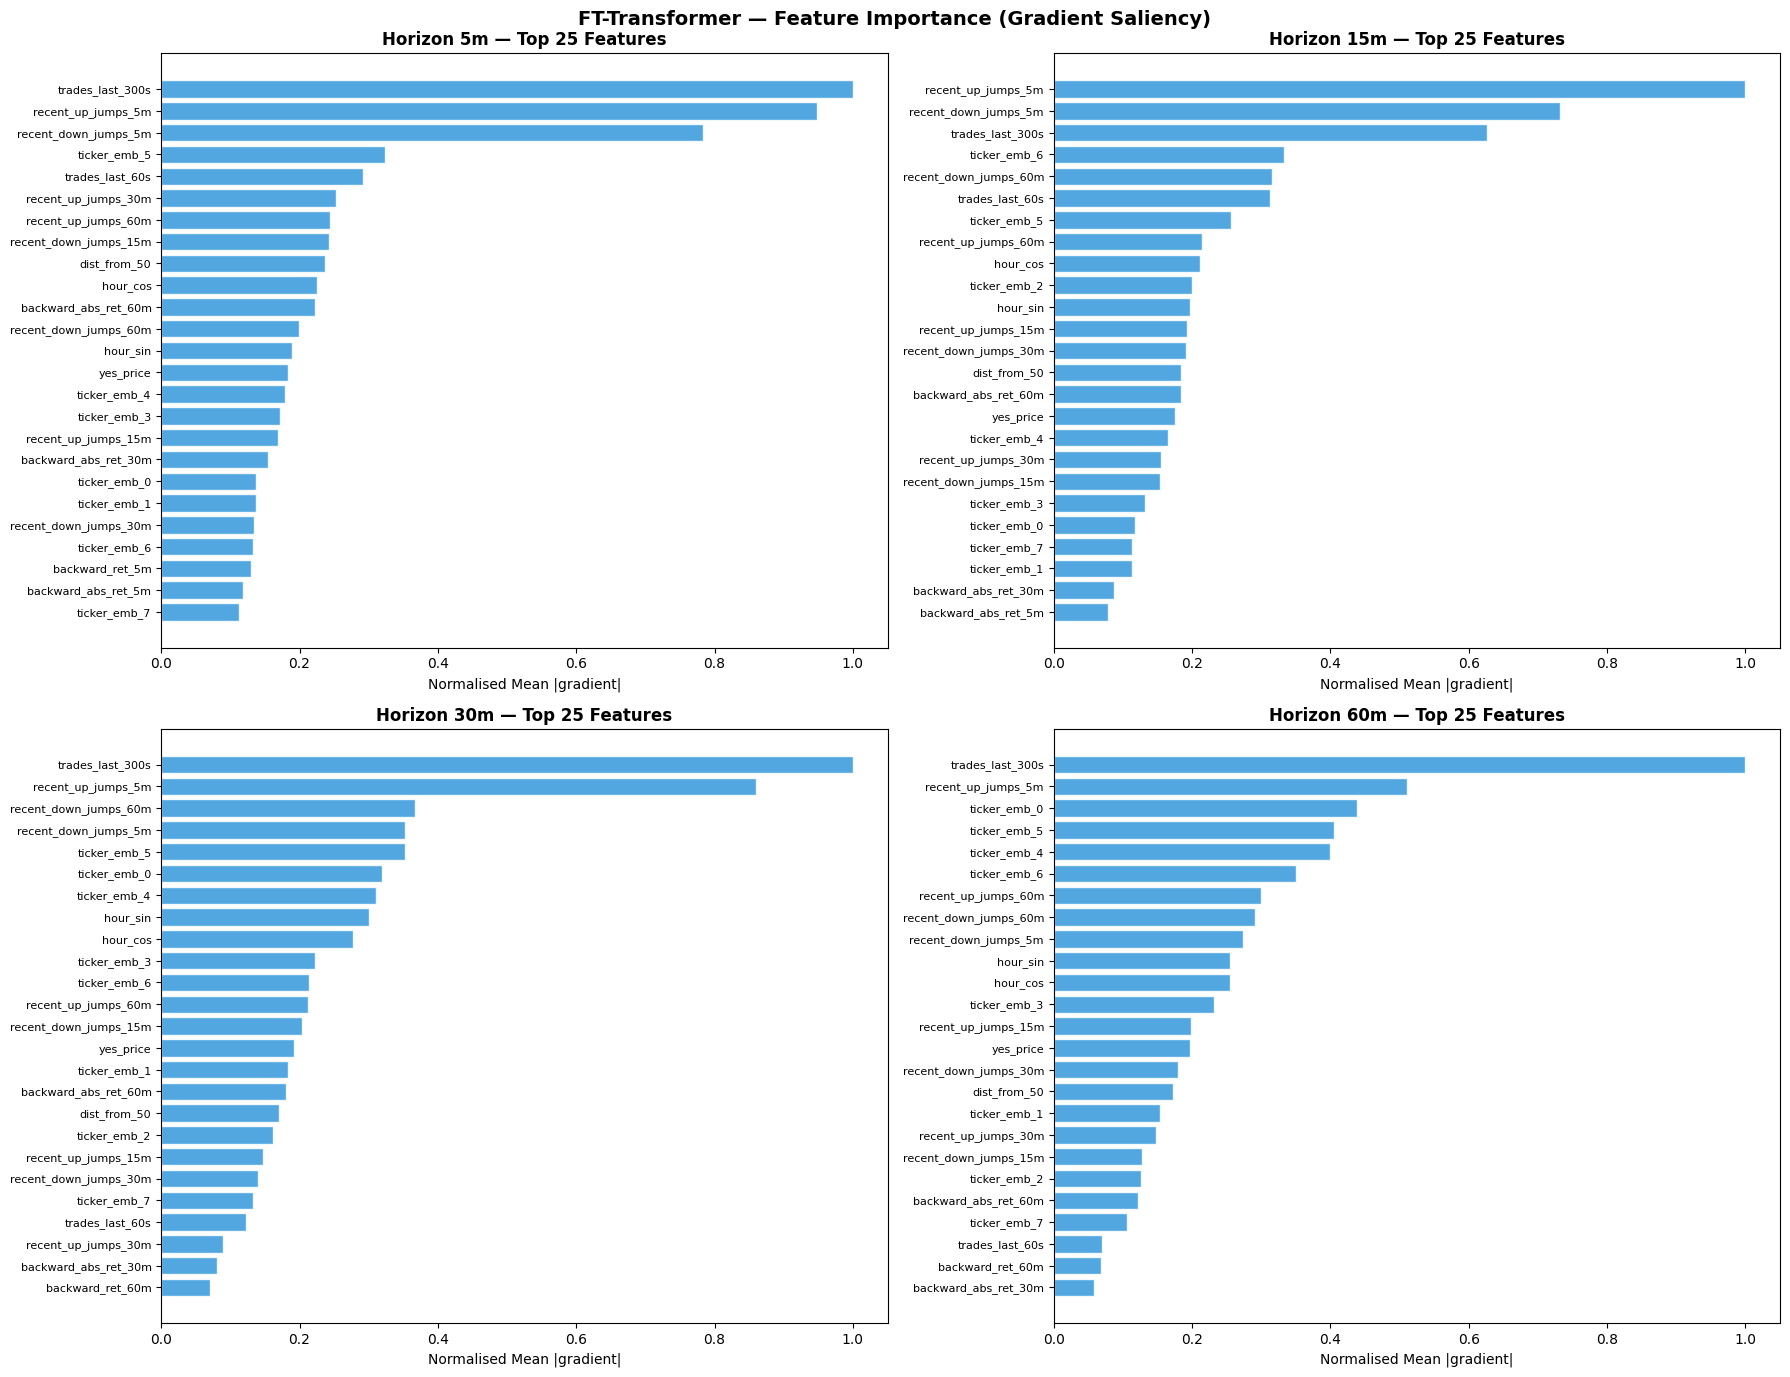

Saved: ftt_top25_features.png


In [ ]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('FT-Transformer — Feature Importance (Gradient Saliency)',
             fontsize=14, fontweight='bold')

for ax, h in zip(axes.flatten(), HORIZONS):
    sal  = saliency_overall[h]
    order = np.argsort(sal)[::-1][:25]
    feats = [FEATURE_COLS[i] for i in order]
    vals  = sal[order]

    # normalise to [0,1] for readability
    vals_norm = vals / vals.max() if vals.max() > 0 else vals

    bars = ax.barh(feats, vals_norm,
                   color='#3498db', alpha=0.85, edgecolor='white')
    ax.set_title(f'Horizon {h}m — Top 25 Features', fontweight='bold')
    ax.set_xlabel('Normalised Mean |gradient|')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ft_transformer_prep/plots/ftt_top25_features.png',
            bbox_inches='tight', dpi=200)
plt.show()
print('Saved: ftt_top25_features.png')

In [1]:
!pip install -q rtdl --no-deps
import os, gc, json, pickle
import numpy as np
import torch
import rtdl
from google.colab import drive

drive.mount('/content/drive')

PREP_DIR = '/content/drive/MyDrive/ft_transformer_prep'
CKPT_DIR = os.path.join(PREP_DIR, 'checkpoints')
HORIZONS = [5, 15, 30, 60]
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)

N_FEATURES   = meta['n_features']
FEATURE_COLS = meta['feature_cols']

with open(os.path.join(PREP_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

models = {}
for h in HORIZONS:
    ckpt_path = os.path.join(CKPT_DIR, f'horizon_{h}m', 'best.pt')
    model = rtdl.FTTransformer.make_default(
        n_num_features=N_FEATURES, cat_cardinalities=[],
        last_layer_query_idx=[-1], d_out=3)
    state = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(state if not (isinstance(state, dict) and 'model' in state)
                          else state['model'])
    model.eval()
    models[h] = model
    print(f'  horizon {h}m loaded ✅')

print(f'Device     : {DEVICE}')
print(f'N_FEATURES : {N_FEATURES}')
print(f'Scaler     : {type(scaler).__name__}')
print('Ready.')

Mounted at /content/drive
  horizon 5m loaded ✅
  horizon 15m loaded ✅
  horizon 30m loaded ✅
  horizon 60m loaded ✅
Device     : cuda
N_FEATURES : 40
Scaler     : StandardScaler
Ready.


In [2]:
# =============================================================================
# FT-TRANSFORMER — Generate predictions parquet for MoE ensemble
# =============================================================================
# Output format requested:
#   ticker, created_time,
#   probability_no_jump_{h}m_ftt,
#   probability_up_{h}m_ftt,
#   probability_down_{h}m_ftt
#   (for h in 5, 15, 30, 60)
# =============================================================================

import os, gc, json
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import torch

PREP_DIR     = '/content/drive/MyDrive/ft_transformer_prep'
PARQUET_PATH = '/content/drive/MyDrive/all_trades_features.parquet'
OUT_PATH     = '/content/drive/MyDrive/ftt_predictions.parquet'
HORIZONS     = [5, 15, 30, 60]
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 8192
MODEL_NAME   = 'ftt'

with open(os.path.join(PREP_DIR, 'meta.json')) as f:
    meta = json.load(f)

N_FEATURES   = meta['n_features']
FEATURE_COLS = meta['feature_cols']

import pickle
with open(os.path.join(PREP_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

# Models must already be in memory from verify script.
# If not, reload them:
import rtdl
from google.colab import drive
drive.mount('/content/drive')

if 'models' not in dir() or len(models) < 4:
    from pathlib import Path
    models = {}
    CKPT_DIR = os.path.join(PREP_DIR, 'checkpoints')
    for h in HORIZONS:
        ckpt_path = os.path.join(CKPT_DIR, f'horizon_{h}m', 'best.pt')
        model = rtdl.FTTransformer.make_default(
            n_num_features=N_FEATURES, cat_cardinalities=[],
            last_layer_query_idx=[-1], d_out=3)
        state = torch.load(ckpt_path, map_location='cpu')
        model.load_state_dict(state if not (isinstance(state, dict) and 'model' in state)
                              else state['model'])
        model.eval()
        models[h] = model
    print('Models reloaded.')

# ── Read parquet in chunks, run inference, write output ──────────────────────
# We read ticker + created_time + features from the original parquet,
# apply the same scaler, run all 4 models, and collect probabilities.

print('Reading parquet and running inference...')
pf        = pq.ParquetFile(PARQUET_PATH)
READ_COLS = ['ticker', 'created_time'] + FEATURE_COLS
CHUNK     = 500_000

# Collect results as list of dicts, then concat at end
results = []

# Put all models on GPU once
for h in HORIZONS:
    models[h] = models[h].to(DEVICE)
    models[h].eval()

total_rows = 0

for batch in pf.iter_batches(batch_size=CHUNK, columns=READ_COLS):
    df = batch.to_pandas()

    # Extract identifiers
    tickers = df['ticker'].values
    times   = df['created_time'].values

    # Features: clean + scale
    X = df[FEATURE_COLS].values.astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    X = np.nan_to_num(X, nan=0.0)
    X = scaler.transform(X).astype(np.float32)

    # Run inference for all 4 horizons
    probs_dict = {h: [] for h in HORIZONS}

    with torch.no_grad():
        for i in range(0, len(X), BATCH_SIZE):
            xb = torch.from_numpy(X[i:i+BATCH_SIZE]).to(DEVICE)
            for h in HORIZONS:
                logits = models[h](xb, None)
                p = torch.softmax(logits, dim=-1).cpu().numpy()
                probs_dict[h].append(p)

    # Concatenate batch results
    chunk_probs = {h: np.concatenate(probs_dict[h], axis=0) for h in HORIZONS}

    # Build chunk dataframe
    chunk_df = pd.DataFrame({
        'ticker'       : tickers,
        'created_time' : times,
    })

    # Add probabilities: class order is 0=down, 1=none, 2=up
    for h in HORIZONS:
        p = chunk_probs[h]
        chunk_df[f'probability_down_{h}m_{MODEL_NAME}']    = p[:, 0].astype(np.float32)
        chunk_df[f'probability_no_jump_{h}m_{MODEL_NAME}'] = p[:, 1].astype(np.float32)
        chunk_df[f'probability_up_{h}m_{MODEL_NAME}']      = p[:, 2].astype(np.float32)

    results.append(chunk_df)
    total_rows += len(df)
    print(f'  {total_rows:,} rows processed ...', end='\r')

    del df, X, chunk_probs
    gc.collect()

# Move models back to CPU
for h in HORIZONS:
    models[h].to('cpu')
torch.cuda.empty_cache()

print(f'\nAll {total_rows:,} rows processed.')

# ── Concatenate and save ──────────────────────────────────────────────────────
print('Concatenating results...')
out_df = pd.concat(results, ignore_index=True)
del results
gc.collect()

print(f'Output shape: {out_df.shape}')
print(f'Columns: {list(out_df.columns)}')
print(f'\nSample:\n{out_df.head(3).to_string()}')

print(f'\nSaving to {OUT_PATH} ...')
out_df.to_parquet(OUT_PATH, index=False, compression='zstd', engine='pyarrow')

size_mb = os.path.getsize(OUT_PATH) / 1e6
print(f'Saved. File size: {size_mb:.1f} MB')
print('\nDone. Send ftt_predictions.parquet to Andres.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading parquet and running inference...
  63,801,798 rows processed ...
All 63,801,798 rows processed.
Concatenating results...
Output shape: (63801798, 14)
Columns: ['ticker', 'created_time', 'probability_down_5m_ftt', 'probability_no_jump_5m_ftt', 'probability_up_5m_ftt', 'probability_down_15m_ftt', 'probability_no_jump_15m_ftt', 'probability_up_15m_ftt', 'probability_down_30m_ftt', 'probability_no_jump_30m_ftt', 'probability_up_30m_ftt', 'probability_down_60m_ftt', 'probability_no_jump_60m_ftt', 'probability_up_60m_ftt']

Sample:
                      ticker               created_time  probability_down_5m_ftt  probability_no_jump_5m_ftt  probability_up_5m_ftt  probability_down_15m_ftt  probability_no_jump_15m_ftt  probability_up_15m_ftt  probability_down_30m_ftt  probability_no_jump_30m_ftt  probability_up_30m_ftt  probability_down_60m_ftt  probability_no